# Model Complexity, the Bias–Variance Trade-off,

This notebook builds up one idea at a time, in three parts.

**Part 1 — Model complexity and test error (real data: Mall Customers).**
We fit regression models of increasing complexity to a real dataset and watch what happens to
training error and test error. This is where *underfitting* and *overfitting* are first observed.

**Part 2 — The bias–variance trade-off (synthetic data).**
Real data only gives us one training sample, and we never know the true underlying function.
A synthetic dataset lets us control both, so we can *measure* bias and variance instead of only
talking about them.

# Part 1 — Model Complexity vs. Test Error (Mall Customers Dataset)

We use the Mall Customers dataset throughout this part. The regression task is:

$$\text{Spending Score} \approx f(\text{Age})$$

Using a single feature keeps everything plottable, so the effect of model complexity is visible
directly on the fitted curve.

## Loading the Mall Customers Dataset

In [1]:
import requests
import os
import pandas as pd

# URL for the raw Mall_Customers.csv file on GitHub
MALL_CUSTOMERS_URL = "https://raw.githubusercontent.com/Sutanoy/Public-Regression-Datasets/main/Mall_Customers.csv"
MALL_CUSTOMERS_FILENAME = "Mall_Customers.csv"

# Create a directory to store the dataset if it doesn't exist
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

file_path = os.path.join(DATA_DIR, MALL_CUSTOMERS_FILENAME)

# Download the dataset
print(f"Downloading dataset from {MALL_CUSTOMERS_URL} to {file_path}...")
response = requests.get(MALL_CUSTOMERS_URL)
response.raise_for_status() # Raise an exception for HTTP errors

with open(file_path, "wb") as f:
    f.write(response.content)

print("Download complete!")
print("Path to Mall Customers CSV file:", file_path)

# Load the Mall_Customers CSV into a pandas DataFrame
df_mall_customers = pd.read_csv(file_path)

# Display the first 5 rows and info to understand the data structure
print("\nFirst 5 rows of the Mall Customers dataset:")
display(df_mall_customers.head())

print("\nDataFrame Info:")
df_mall_customers.info()

Download complete!
Path to Mall Customers CSV file: ./data/Mall_Customers.csv

First 5 rows of the Mall Customers dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## Data Visualization: Age vs. Spending Score

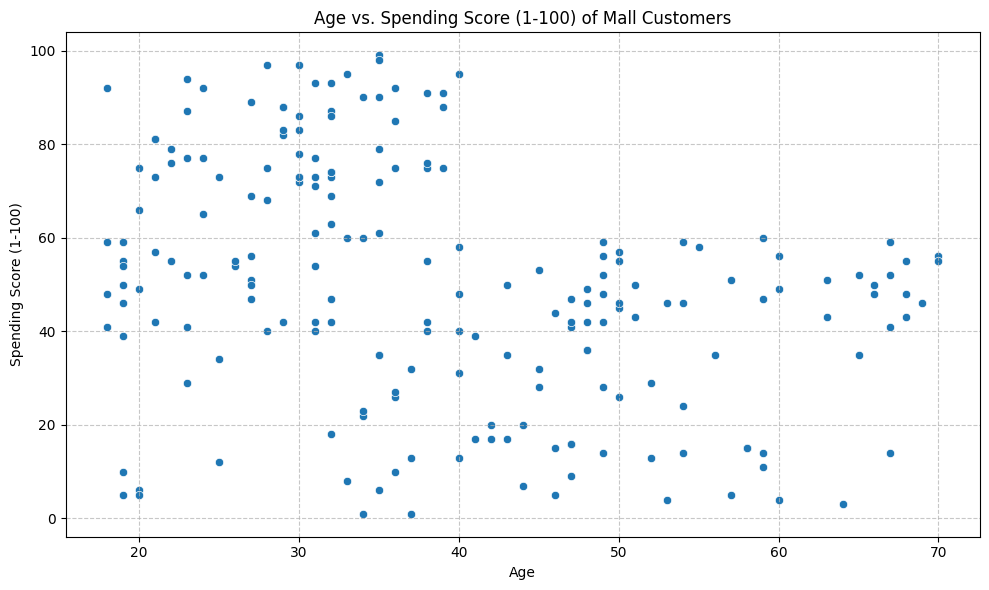

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of Age vs. Spending Score
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df_mall_customers)
plt.title('Age vs. Spending Score (1-100) of Mall Customers')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Splitting the Mall Customers Dataset

In [3]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# We'll consider 'Spending Score (1-100)' as the target for a regression task.
# 'CustomerID' is an identifier and should not be used as a feature.
X = df_mall_customers[['Gender', 'Age', 'Annual Income (k$)']]
y = df_mall_customers['Spending Score (1-100)']

# Note: The 'Gender' column is categorical and would need to be one-hot encoded
# before training a machine learning model. This step is usually done during
# feature engineering after the split to avoid data leakage from validation/test sets.

# Split into training (80%) and temporary (20%) datasets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary into training (75% of 80% = 60% of total) and validation (25% of 80% = 20% of total)
# This results in an approximately 60/20/20 split for train/val/test
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

# Print their lengths to confirm the split sizes
print(f"Length of training features: {len(X_train)}")
print(f"Length of training target: {len(y_train)}")
print(f"Length of validation features: {len(X_val)}")
print(f"Length of validation target: {len(y_val)}")
print(f"Length of test features: {len(X_test)}")
print(f"Length of test target: {len(y_test)}")

print("\nFirst 5 rows of the training features:")
display(X_train.head())
print("\nFirst 5 rows of the training target:")
display(y_train.head())

Length of training features: 120
Length of training target: 120
Length of validation features: 40
Length of validation target: 40
Length of test features: 40
Length of test target: 40

First 5 rows of the training features:


,Gender,Age,Annual Income (k$)
42,Male,48,39
157,Female,30,78
155,Female,27,78
3,Female,23,16
99,Male,20,61



First 5 rows of the training target:


42     36
157    78
155    89
3      77
99     49
Name: Spending Score (1-100), dtype: int64

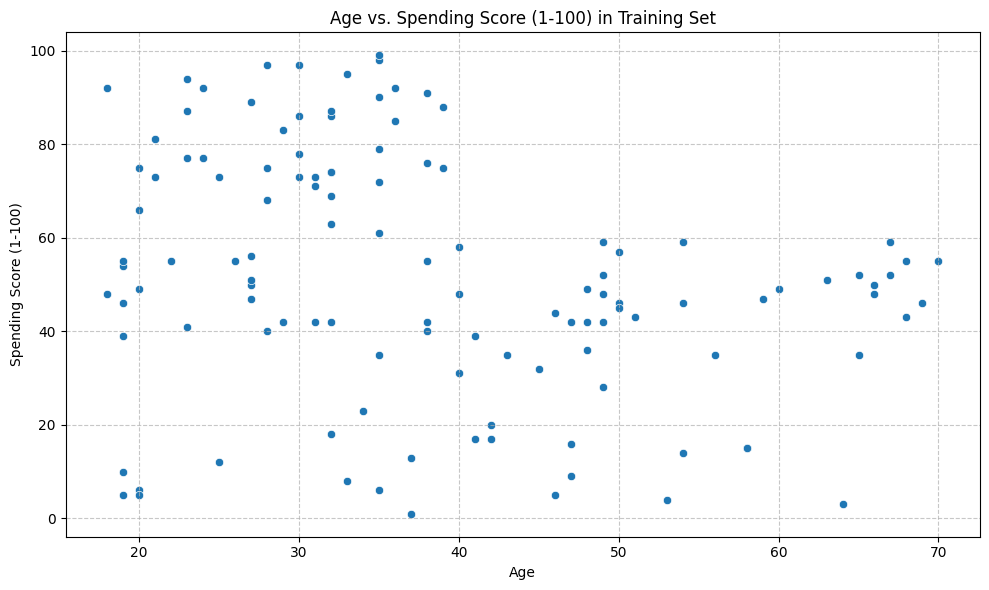

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of Age vs. Spending Score for the training set
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train['Age'], y=y_train)
plt.title('Age vs. Spending Score (1-100) in Training Set')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Combine X_train, X_val, X_test for consistent one-hot encoding
X_combined = pd.concat([X_train, X_val, X_test], ignore_index=True)

# Perform one-hot encoding on the 'Gender' column
X_combined_encoded = pd.get_dummies(X_combined, columns=['Gender'], drop_first=True, dtype=int)

# Split back into training, validation, and test sets
X_train_encoded = X_combined_encoded.iloc[:len(X_train)]
X_val_encoded = X_combined_encoded.iloc[len(X_train):len(X_train) + len(X_val)]
X_test_encoded = X_combined_encoded.iloc[len(X_train) + len(X_val):]

print("Encoded training features (first 5 rows):")
display(X_train_encoded.head())


Encoded training features (first 5 rows):


,Age,Annual Income (k$),Gender_Male
0,48,39,1
1,30,78,0
2,27,78,0
3,23,16,0
4,20,61,1


### Linear Regression with 'Age' as the Sole Feature

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Redefine features (X_train_age) to include only 'Age'
X_train_age = X_train[['Age']]

# Initialize and train a new Linear Regression model using only 'Age'
model_age = LinearRegression()
model_age.fit(X_train_age, y_train)

# Make predictions on the training set using only 'Age'
y_train_pred_age = model_age.predict(X_train_age)

# Calculate Mean Squared Error for the 'Age'-only model
mse_age = mean_squared_error(y_train, y_train_pred_age)

print(f"Model Coefficients (Age-only): {model_age.coef_[0]:.4f}")
print(f"Model Intercept (Age-only): {model_age.intercept_:.4f}")
print(f"Mean Squared Error on the training set (Age-only model): {mse_age:.2f}")

Model Coefficients (Age-only): -0.4991
Model Intercept (Age-only): 70.9186
Mean Squared Error on the training set (Age-only model): 635.37


### Plotting the Regression Line (Age-only Model)

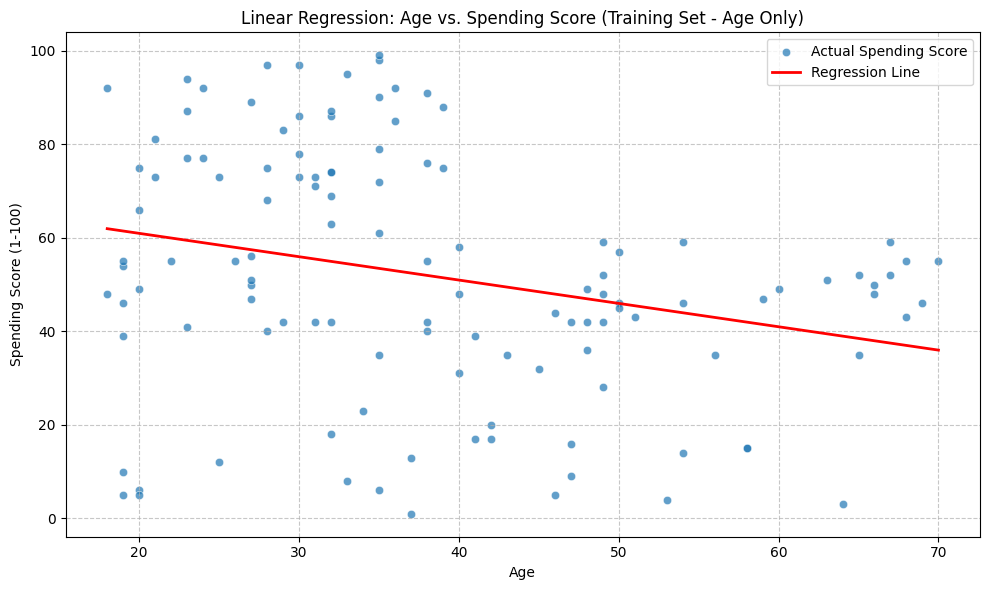

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual Age vs. Spending Score
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_age['Age'], y=y_train, label='Actual Spending Score', alpha=0.7)

# Plot the regression line
sns.lineplot(x=X_train_age['Age'], y=y_train_pred_age, color='red', label='Regression Line', linewidth=2)

plt.title('Linear Regression: Age vs. Spending Score (Training Set - Age Only)')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Increasing model complexity: polynomial regression

A straight line is the simplest model we can fit. To make the model more flexible we replace the
feature $x$ (Age) with the polynomial features $x, x^2, \dots, x^d$ and fit a linear model on top of them:

$$\hat{y} = w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d$$

The model is still *linear in the parameters* (so `LinearRegression` still applies), but the
**polynomial degree $d$ is our complexity knob**: larger $d$ means a more flexible curve.

The cell below fits several degrees on the training set and reports the training MSE for each.
It also reports a *log-likelihood* value — ignore that column for now; we will derive exactly
where it comes from in Part 3.

Order 1 - Mean Squared Error: 635.37
Order 2 - Mean Squared Error: 635.33
Order 4 - Mean Squared Error: 545.50
Order 8 - Mean Squared Error: 543.12
Order 10 - Mean Squared Error: 538.94
Order 12 - Mean Squared Error: 544.52
Order 20 - Mean Squared Error: 591.27


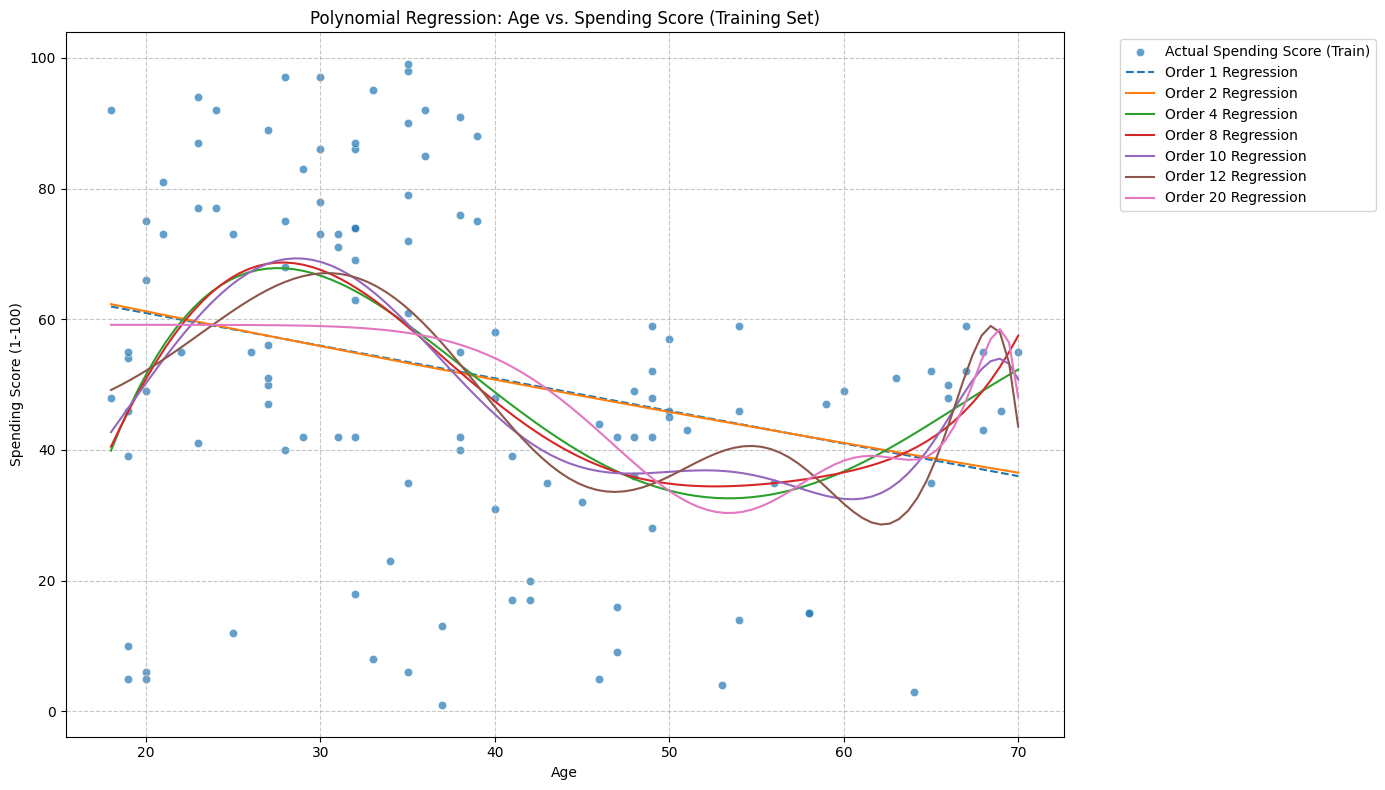

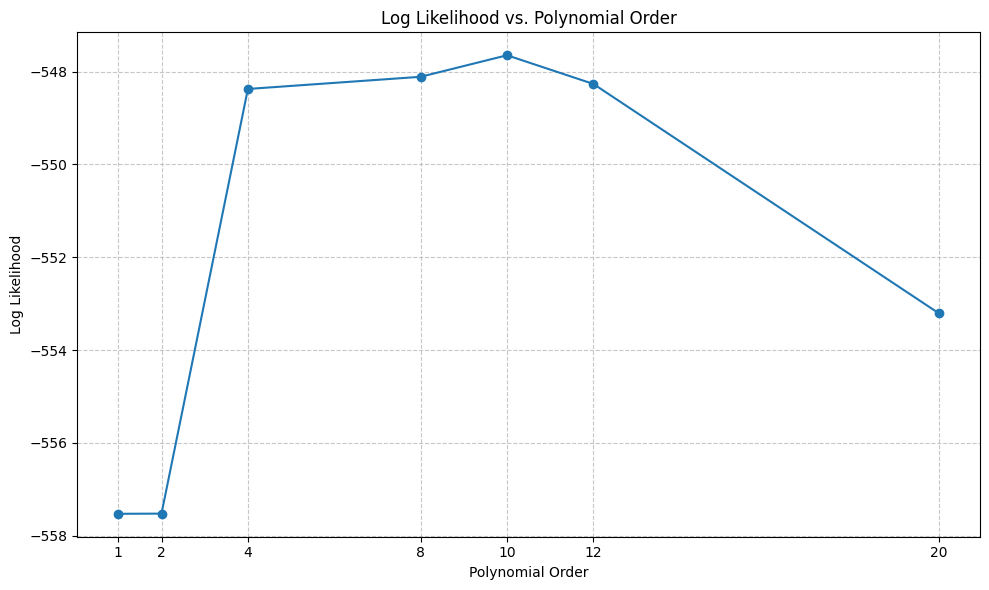

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Define polynomial orders to test, including order 1 for linear regression
polynomial_orders = [1, 2, 4, 8, 10, 12, 20]

# Prepare data for plotting smooth curves
X_plot = pd.DataFrame({'Age': np.linspace(X_train_age['Age'].min(), X_train_age['Age'].max(), 100)}) # 100 points for smooth curve

mse_values = []
log_likelihood_values = []

plt.figure(figsize=(14, 8))
sns.scatterplot(x=X_train_age['Age'], y=y_train, label='Actual Spending Score (Train)', alpha=0.7)

n_samples = len(y_train) # Number of training samples for log-likelihood calculation

for order in polynomial_orders:
    # Create polynomial features
    poly = PolynomialFeatures(degree=order)
    X_train_poly = poly.fit_transform(X_train_age)

    # Train Linear Regression model on polynomial features
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)

    # Make predictions on the training set
    y_train_pred_poly = model_poly.predict(X_train_poly)

    # Calculate MSE
    mse = mean_squared_error(y_train, y_train_pred_poly)
    mse_values.append(mse)

    # Calculate Log Likelihood (assuming Gaussian errors and sigma^2 = MSE)
    # L = -n/2 * (log(2*pi) + log(MSE) + 1)
    log_likelihood = - (n_samples / 2) * (np.log(2 * np.pi) + np.log(mse) + 1)
    log_likelihood_values.append(log_likelihood)

    # Predict for plotting smooth curves
    X_plot_poly = poly.transform(X_plot)
    y_plot_pred_poly = model_poly.predict(X_plot_poly)

    # Plot the regression line
    plt.plot(X_plot['Age'], y_plot_pred_poly, label=f'Order {order} Regression', linestyle='--' if order == 1 else '-')

    print(f"Order {order} - Mean Squared Error: {mse:.2f}")

plt.title('Polynomial Regression: Age vs. Spending Score (Training Set)')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot Log Likelihood vs. Order
plt.figure(figsize=(10, 6))
plt.plot(polynomial_orders, log_likelihood_values, marker='o', linestyle='-')
plt.title('Log Likelihood vs. Polynomial Order')
plt.xlabel('Polynomial Order')
plt.ylabel('Log Likelihood')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(polynomial_orders)
plt.tight_layout()
plt.show()


### The same models fitted on a smaller training sample

The next few cells repeat the experiment on a random subsample of 50 training points. With less
data, a flexible model has more room to chase individual points, so the effect of complexity is
easier to see.

In [9]:
# Take 50 random samples from the training data
np.random.seed(42) # for reproducibility
sample_indices = np.random.choice(X_train_age.index, size=50, replace=False)

X_train_age_sampled = X_train_age.loc[sample_indices]
y_train_sampled = y_train.loc[sample_indices]

print(f"Number of sampled training features: {len(X_train_age_sampled)}")
print(f"Number of sampled training target: {len(y_train_sampled)}")

# Display first 5 rows of sampled data
print("\nFirst 5 rows of sampled X_train_age:")
display(X_train_age_sampled.head())
print("\nFirst 5 rows of sampled y_train:")
display(y_train_sampled.head())


Number of sampled training features: 50
Number of sampled training target: 50

First 5 rows of sampled X_train_age:


,Age
14,37
36,42
99,20
142,28
114,18



First 5 rows of sampled y_train:


14     13
36     17
99     49
142    40
114    48
Name: Spending Score (1-100), dtype: int64

### Polynomial Regression with 50 Samples (Training Set)

Order 1 - Mean Squared Error: 626.94
Order 2 - Mean Squared Error: 596.59
Order 4 - Mean Squared Error: 511.49
Order 8 - Mean Squared Error: 507.85
Order 10 - Mean Squared Error: 505.72
Order 12 - Mean Squared Error: 495.63
Order 20 - Mean Squared Error: 571.34


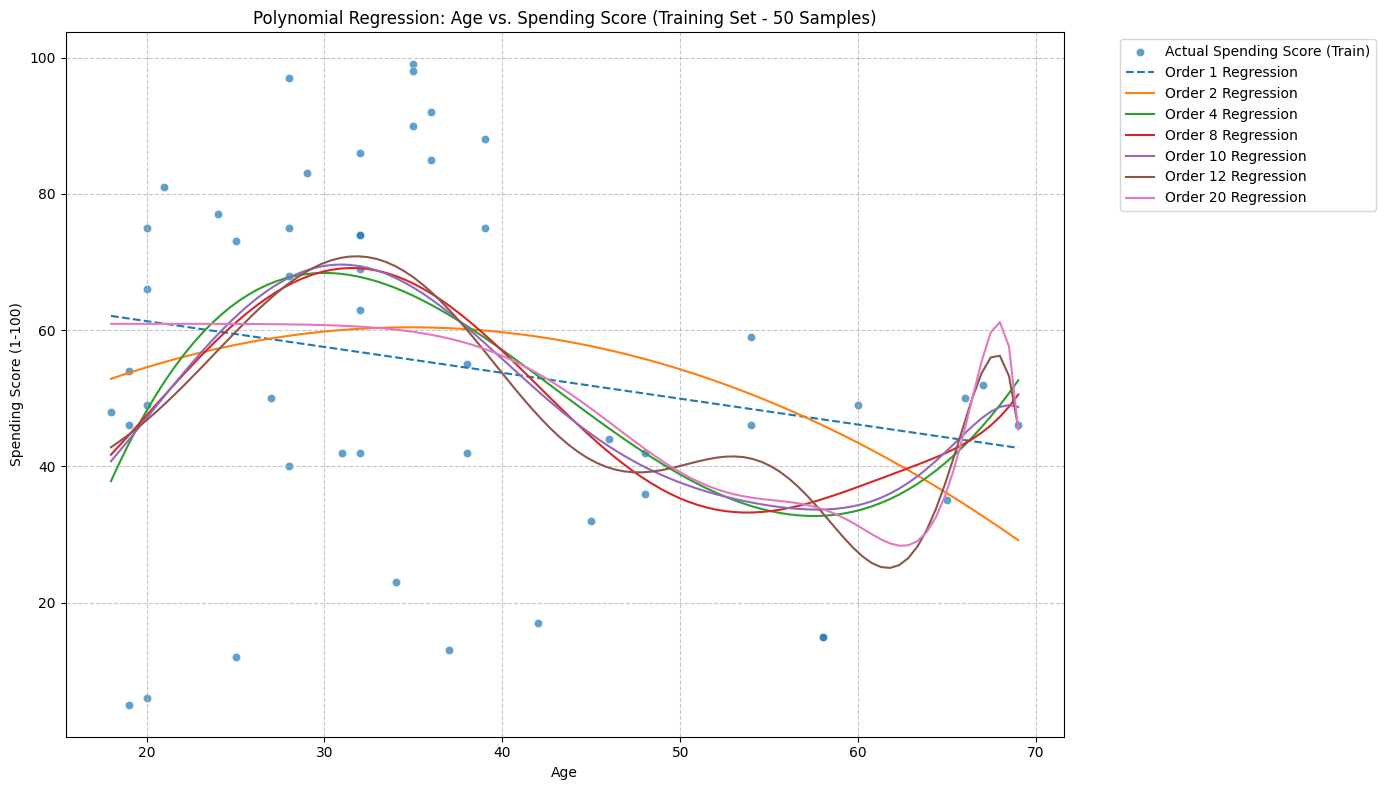

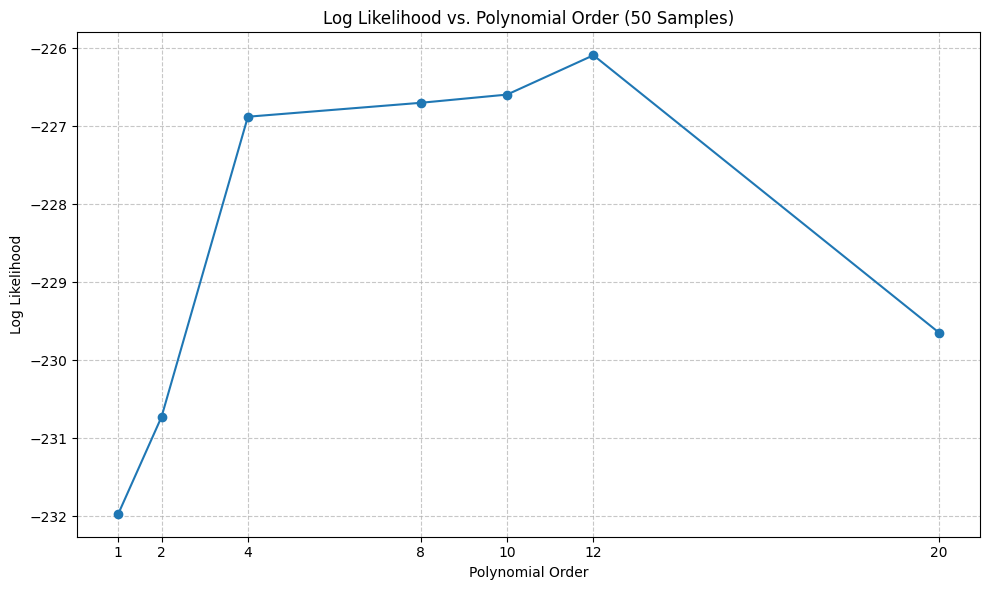

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Define polynomial orders to test, including order 1 for linear regression
polynomial_orders = [1, 2, 4, 8, 10, 12, 20]

# Prepare data for plotting smooth curves
X_plot = pd.DataFrame({'Age': np.linspace(X_train_age_sampled['Age'].min(), X_train_age_sampled['Age'].max(), 100)}) # 100 points for smooth curve

mse_values = []
log_likelihood_values = []

plt.figure(figsize=(14, 8))
sns.scatterplot(x=X_train_age_sampled['Age'], y=y_train_sampled, label='Actual Spending Score (Train)', alpha=0.7)

n_samples = len(y_train_sampled) # Number of training samples for log-likelihood calculation

for order in polynomial_orders:
    # Create polynomial features
    poly = PolynomialFeatures(degree=order)
    X_train_poly = poly.fit_transform(X_train_age_sampled)

    # Train Linear Regression model on polynomial features
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train_sampled)

    # Make predictions on the training set
    y_train_pred_poly = model_poly.predict(X_train_poly)

    # Calculate MSE
    mse = mean_squared_error(y_train_sampled, y_train_pred_poly)
    mse_values.append(mse)

    # Calculate Log Likelihood (assuming Gaussian errors and sigma^2 = MSE)
    # L = -n/2 * (log(2*pi) + log(MSE) + 1)
    log_likelihood = - (n_samples / 2) * (np.log(2 * np.pi) + np.log(mse) + 1)
    log_likelihood_values.append(log_likelihood)

    # Predict for plotting smooth curves
    X_plot_poly = poly.transform(X_plot)
    y_plot_pred_poly = model_poly.predict(X_plot_poly)

    # Plot the regression line
    plt.plot(X_plot['Age'], y_plot_pred_poly, label=f'Order {order} Regression', linestyle='--' if order == 1 else '-')

    print(f"Order {order} - Mean Squared Error: {mse:.2f}")

plt.title('Polynomial Regression: Age vs. Spending Score (Training Set - 50 Samples)')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot Log Likelihood vs. Order
plt.figure(figsize=(10, 6))
plt.plot(polynomial_orders, log_likelihood_values, marker='o', linestyle='-')
plt.title('Log Likelihood vs. Polynomial Order (50 Samples)')
plt.xlabel('Polynomial Order')
plt.ylabel('Log Likelihood')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(polynomial_orders)
plt.tight_layout()
plt.show()


### Polynomial Regression with 50 Samples (Test Set)


--- Test Set Evaluation ---
Order 1 - Mean Squared Error on Test Set: 525.75
Order 2 - Mean Squared Error on Test Set: 624.62
Order 4 - Mean Squared Error on Test Set: 485.99
Order 8 - Mean Squared Error on Test Set: 483.52
Order 10 - Mean Squared Error on Test Set: 478.33
Order 12 - Mean Squared Error on Test Set: 518.12
Order 20 - Mean Squared Error on Test Set: 603.25


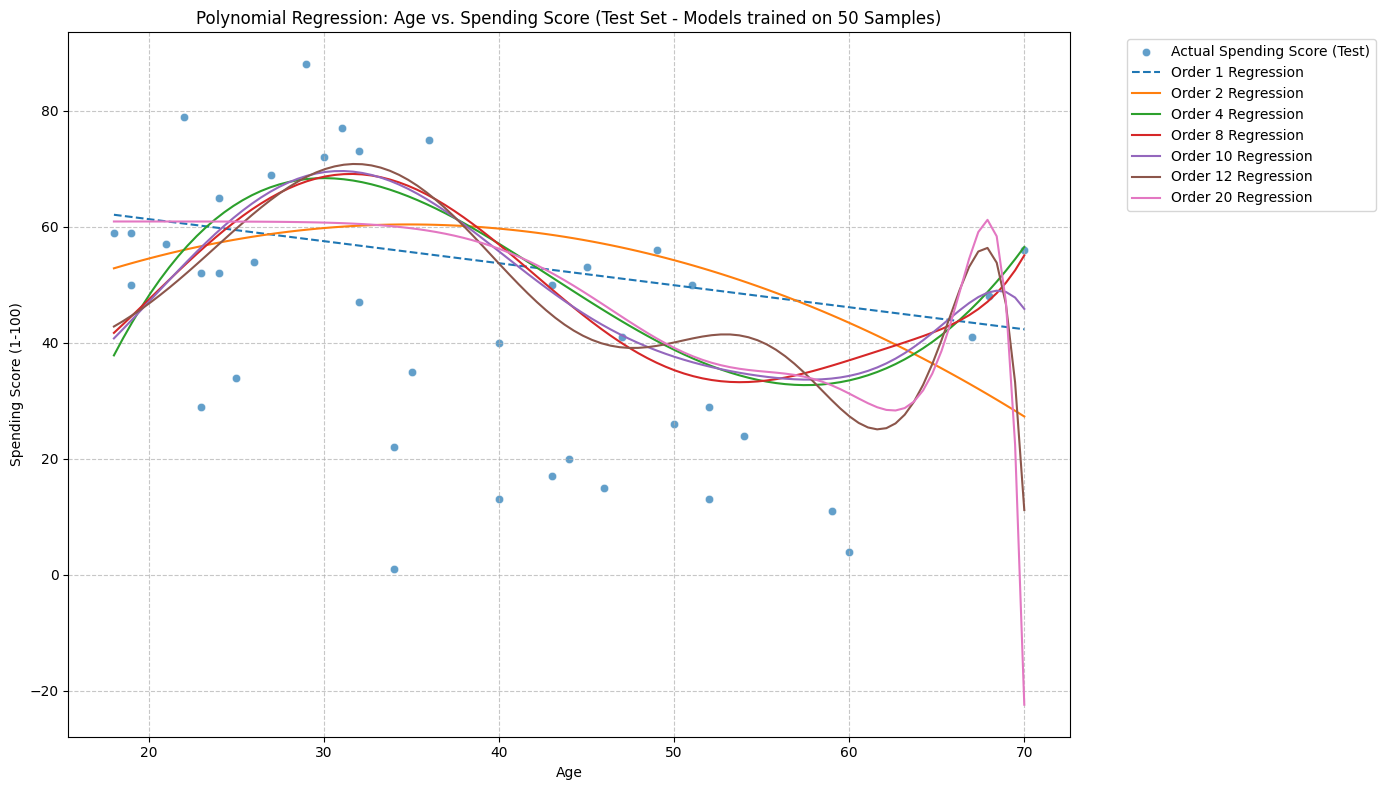

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Redefine X_test_age for consistency, using only 'Age' from the test set
X_test_age = X_test[['Age']]

# Define polynomial orders to test
polynomial_orders = [1, 2, 4, 8, 10, 12, 20]

# Prepare data for plotting smooth curves across the age range observed in training
X_plot_test = pd.DataFrame({'Age': np.linspace(X_test_age['Age'].min(), X_test_age['Age'].max(), 100)}) # 100 points for smooth curve

mse_test_values = []

plt.figure(figsize=(14, 8))
sns.scatterplot(x=X_test_age['Age'], y=y_test, label='Actual Spending Score (Test)', alpha=0.7)

print("\n--- Test Set Evaluation ---")
for order in polynomial_orders:
    # Create polynomial features (trained on training data, applied to test and plot data)
    poly = PolynomialFeatures(degree=order)

    # Transform training data to train the model (using sampled training data)
    X_train_poly = poly.fit_transform(X_train_age_sampled)

    # Train Linear Regression model
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train_sampled)

    # Make predictions on the test set
    X_test_poly = poly.transform(X_test_age)
    y_test_pred_poly = model_poly.predict(X_test_poly)

    # Calculate MSE on the test set
    mse_test = mean_squared_error(y_test, y_test_pred_poly)
    mse_test_values.append(mse_test)

    # Predict for plotting smooth curves (using a continuous range)
    X_plot_poly_test = poly.transform(X_plot_test)
    y_plot_pred_poly_test = model_poly.predict(X_plot_poly_test)

    # Plot the regression line
    plt.plot(X_plot_test['Age'], y_plot_pred_poly_test, label=f'Order {order} Regression', linestyle='--' if order == 1 else '-')

    print(f"Order {order} - Mean Squared Error on Test Set: {mse_test:.2f}")

plt.title('Polynomial Regression: Age vs. Spending Score (Test Set - Models trained on 50 Samples)')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



--- Test Set Evaluation ---
Order 1 - Mean Squared Error on Test Set: 467.74
Order 2 - Mean Squared Error on Test Set: 465.56
Order 4 - Mean Squared Error on Test Set: 419.83
Order 8 - Mean Squared Error on Test Set: 415.02
Order 10 - Mean Squared Error on Test Set: 399.91
Order 12 - Mean Squared Error on Test Set: 408.00
Order 20 - Mean Squared Error on Test Set: 426.51


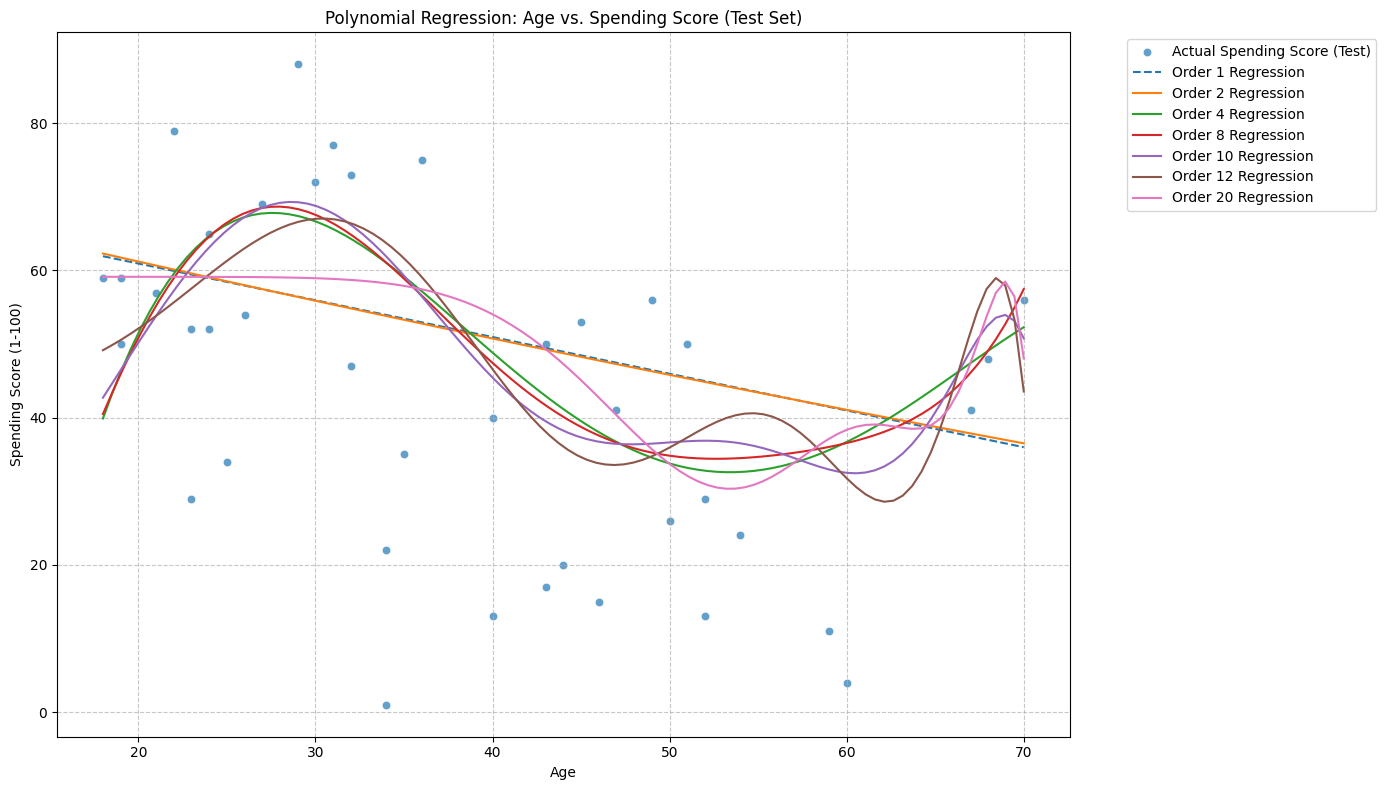

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Redefine X_test_age for consistency, using only 'Age' from the test set
X_test_age = X_test[['Age']]

# Define polynomial orders to test
polynomial_orders = [1, 2, 4, 8, 10, 12, 20]

# Prepare data for plotting smooth curves across the age range observed in training
X_plot_test = pd.DataFrame({'Age': np.linspace(X_test_age['Age'].min(), X_test_age['Age'].max(), 100)}) # 100 points for smooth curve

mse_test_values = []

plt.figure(figsize=(14, 8))
sns.scatterplot(x=X_test_age['Age'], y=y_test, label='Actual Spending Score (Test)', alpha=0.7)

print("\n--- Test Set Evaluation ---")
for order in polynomial_orders:
    # Create polynomial features (trained on training data, applied to test and plot data)
    poly = PolynomialFeatures(degree=order)

    # Transform training data to train the model
    X_train_poly = poly.fit_transform(X_train_age)

    # Train Linear Regression model
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)

    # Make predictions on the test set
    X_test_poly = poly.transform(X_test_age)
    y_test_pred_poly = model_poly.predict(X_test_poly)

    # Calculate MSE on the test set
    mse_test = mean_squared_error(y_test, y_test_pred_poly)
    mse_test_values.append(mse_test)

    # Predict for plotting smooth curves (using a continuous range)
    X_plot_poly_test = poly.transform(X_plot_test)
    y_plot_pred_poly_test = model_poly.predict(X_plot_poly_test)

    # Plot the regression line
    plt.plot(X_plot_test['Age'], y_plot_pred_poly_test, label=f'Order {order} Regression', linestyle='--' if order == 1 else '-')

    print(f"Order {order} - Mean Squared Error on Test Set: {mse_test:.2f}")

plt.title('Polynomial Regression: Age vs. Spending Score (Test Set)')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Training error and test error on the same axes

So far training error and test error have been printed in separate cells. To see the relationship
between them we now compute both for the same set of models and plot them together against complexity.

One practical note about the code below: we apply a `MinMaxScaler` to Age *before* the polynomial
expansion. Age ranges from roughly 18 to 70, so $\text{Age}^{20}$ is an astronomically large number
and the least-squares solve becomes dominated by floating-point round-off. Rescaling Age to
$[-1, 1]$ first fixes this. Without it, the training-error curve at high degree reflects numerical
error rather than model complexity.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Complexity levels to compare (the polynomial degree is our complexity parameter)
complexity_orders = [1, 2, 3, 4, 6, 8, 10, 12, 15, 20]

# Age-only features for train and test (X_test_age was defined earlier, repeated for clarity)
X_train_age = X_train[['Age']]
X_test_age = X_test[['Age']]

train_mse_full = []
test_mse_full = []

for order in complexity_orders:
    # Scale Age to [-1, 1] before the polynomial expansion so high powers stay numerically stable
    model_poly = make_pipeline(
        MinMaxScaler(feature_range=(-1, 1)),
        PolynomialFeatures(degree=order),
        LinearRegression()
    )
    model_poly.fit(X_train_age, y_train)

    train_mse_full.append(mean_squared_error(y_train, model_poly.predict(X_train_age)))
    test_mse_full.append(mean_squared_error(y_test, model_poly.predict(X_test_age)))

print(f"Training samples: {len(y_train)}   Test samples: {len(y_test)}\n")
print(f"{'Degree':>8} {'Train MSE':>12} {'Test MSE':>12}")
for order, tr, te in zip(complexity_orders, train_mse_full, test_mse_full):
    print(f"{order:>8} {tr:>12.2f} {te:>12.2f}")

best_order = complexity_orders[int(np.argmin(test_mse_full))]
print(f"\nLowest test MSE at degree {best_order} (test MSE = {min(test_mse_full):.2f})")

Training samples: 120   Test samples: 40

  Degree    Train MSE     Test MSE
       1       635.37       467.74
       2       635.33       465.56
       3       553.05       406.25
       4       545.50       419.83
       6       542.69       413.09
       8       539.83       395.37
      10       510.07       453.09
      12       502.61       473.21
      15       470.79       487.01
      20       459.67       460.56

Lowest test MSE at degree 8 (test MSE = 395.37)


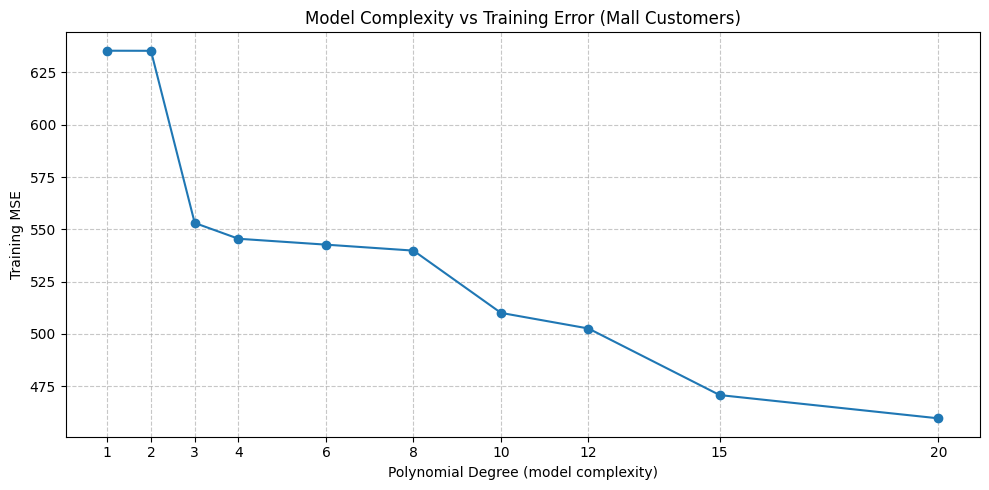

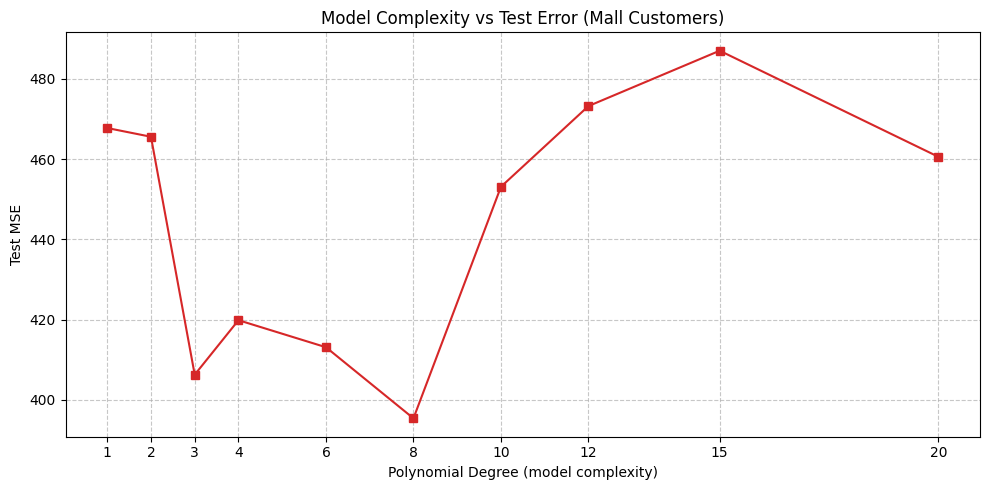

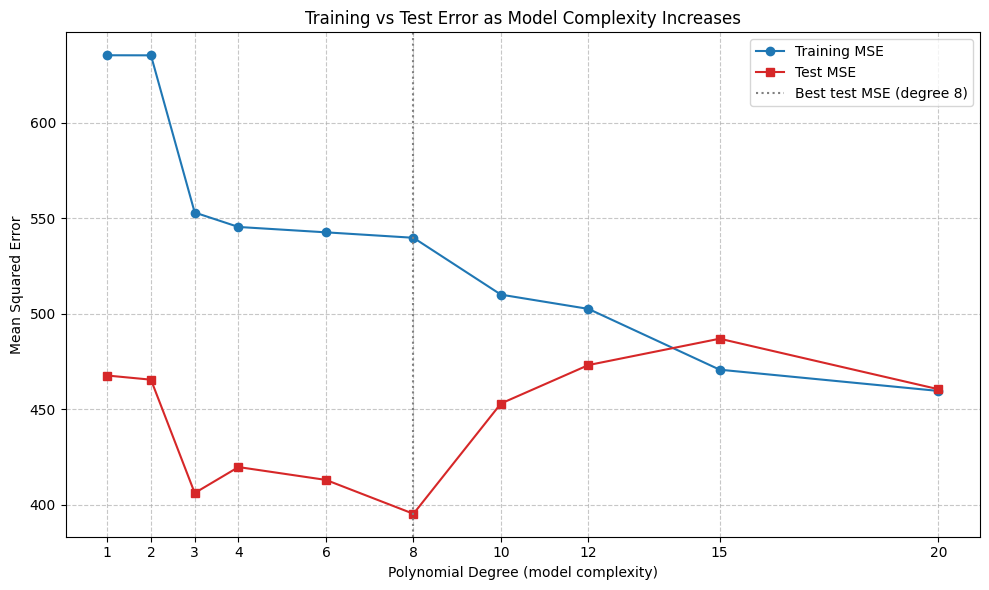

In [14]:
# Plot 1: model complexity vs training error
plt.figure(figsize=(10, 5))
plt.plot(complexity_orders, train_mse_full, marker='o', color='tab:blue')
plt.title('Model Complexity vs Training Error (Mall Customers)')
plt.xlabel('Polynomial Degree (model complexity)')
plt.ylabel('Training MSE')
plt.xticks(complexity_orders)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 2: model complexity vs test error
plt.figure(figsize=(10, 5))
plt.plot(complexity_orders, test_mse_full, marker='s', color='tab:red')
plt.title('Model Complexity vs Test Error (Mall Customers)')
plt.xlabel('Polynomial Degree (model complexity)')
plt.ylabel('Test MSE')
plt.xticks(complexity_orders)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 3: both curves together
plt.figure(figsize=(10, 6))
plt.plot(complexity_orders, train_mse_full, marker='o', color='tab:blue', label='Training MSE')
plt.plot(complexity_orders, test_mse_full, marker='s', color='tab:red', label='Test MSE')
plt.axvline(best_order, color='gray', linestyle=':', label=f'Best test MSE (degree {best_order})')
plt.title('Training vs Test Error as Model Complexity Increases')
plt.xlabel('Polynomial Degree (model complexity)')
plt.ylabel('Mean Squared Error')
plt.xticks(complexity_orders)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

The training set here has only 120 points and the test set only 40, so both curves are noisy.
The effect becomes much sharper when the model has even less data to learn from. Below we repeat
exactly the same sweep using the 50-sample training subset created earlier, and evaluate on the
same test set.

Training samples: 50   Test samples: 40

  Degree    Train MSE       Test MSE
       1       626.94         525.75
       2       596.59         624.62
       3       511.86         486.22
       4       511.49         485.99
       6       508.38         480.36
       8       491.47         501.08
      10       470.06         544.97
      12       469.77         546.06
      15       436.67        3580.05
      20       367.36   543820943.61

Lowest test MSE at degree 6 (test MSE = 480.36)


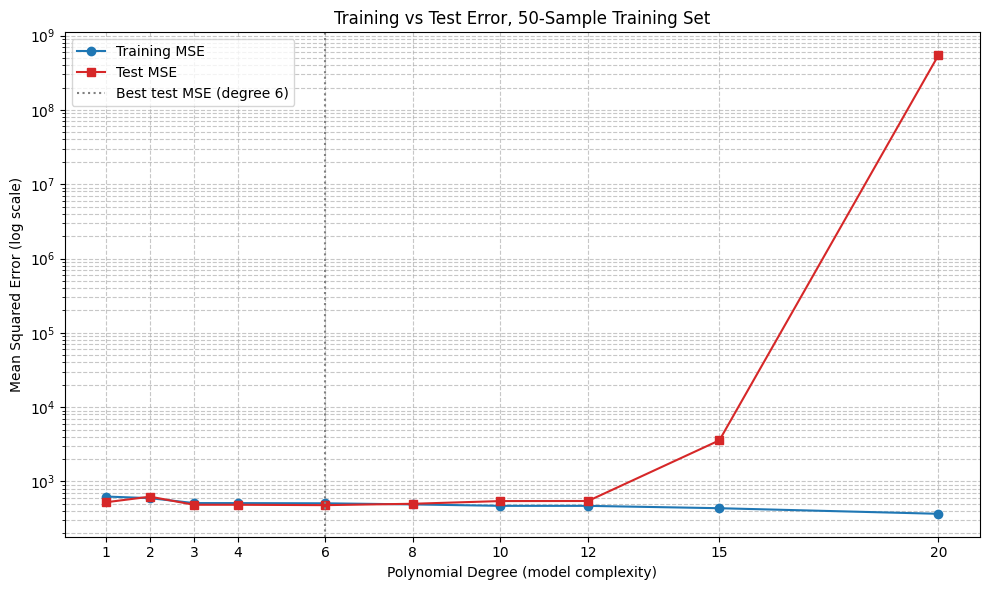

In [15]:
train_mse_sampled = []
test_mse_sampled = []

for order in complexity_orders:
    model_poly = make_pipeline(
        MinMaxScaler(feature_range=(-1, 1)),
        PolynomialFeatures(degree=order),
        LinearRegression()
    )
    model_poly.fit(X_train_age_sampled, y_train_sampled)

    train_mse_sampled.append(mean_squared_error(y_train_sampled, model_poly.predict(X_train_age_sampled)))
    test_mse_sampled.append(mean_squared_error(y_test, model_poly.predict(X_test_age)))

print(f"Training samples: {len(y_train_sampled)}   Test samples: {len(y_test)}\n")
print(f"{'Degree':>8} {'Train MSE':>12} {'Test MSE':>14}")
for order, tr, te in zip(complexity_orders, train_mse_sampled, test_mse_sampled):
    print(f"{order:>8} {tr:>12.2f} {te:>14.2f}")

best_order_sampled = complexity_orders[int(np.argmin(test_mse_sampled))]
print(f"\nLowest test MSE at degree {best_order_sampled} (test MSE = {min(test_mse_sampled):.2f})")

# Both curves together. The test error at high degree is orders of magnitude larger than the
# training error, so a log scale is used to keep both visible on one axis.
plt.figure(figsize=(10, 6))
plt.plot(complexity_orders, train_mse_sampled, marker='o', color='tab:blue', label='Training MSE')
plt.plot(complexity_orders, test_mse_sampled, marker='s', color='tab:red', label='Test MSE')
plt.axvline(best_order_sampled, color='gray', linestyle=':',
            label=f'Best test MSE (degree {best_order_sampled})')
plt.yscale('log')
plt.title('Training vs Test Error, 50-Sample Training Set')
plt.xlabel('Polynomial Degree (model complexity)')
plt.ylabel('Mean Squared Error (log scale)')
plt.xticks(complexity_orders)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### What did we actually observe?

Read the two experiments together rather than expecting a textbook-perfect curve:

* **Training error** decreases (or at least does not increase) as the degree grows. A more flexible
  model can always bend closer to the points it was shown.
* **Test error** does *not* follow it down. It improves at first, reaches a minimum at a moderate
  degree, and then gets worse — dramatically worse in the 50-sample experiment, where the
  degree-20 test MSE is larger than the degree-6 test MSE by several orders of magnitude.
* On the full 120-point training set the test-error curve is **noticeably bumpy** rather than a clean
  U. With only 40 test points, a single unusual customer moves the test MSE by a lot. The
  qualitative pattern is there, but we should not pretend this curve is smooth — it is not.

The honest summary is:

> A more complex model can fit the training data better while performing **worse** on data it has
> never seen.

Which raises the question this notebook is built around:

> **If a more complex model has lower training error, why does it not always have lower test error?**

Take a moment on this before reading on. Nothing about "the model fits the training data better"
guarantees anything about points that were not in the training data.

### Three regimes

The curves above let us name three situations, purely by what we can see:

**Underfitting (too little complexity).**
Both training error and test error are high. The model is too rigid to represent the pattern in the
data at all — a straight line through a relationship that is not straight.

**A reasonable fit (moderate complexity).**
Training error is low-ish and test error is at (or near) its minimum. The model captures the
structure that generalizes, and ignores the rest.

**Overfitting (too much complexity).**
Training error keeps falling while test error rises. The model is now fitting the particular noise
and quirks of *this* training sample — details that will not repeat in new data.

Notice that we have described *what happens* without yet explaining *why*. The explanation needs
two quantities we cannot compute from a single real dataset: bias and variance. That is Part 2.

### One more clue: the fit depends on which points we happened to collect

Before moving on, look at what happens when we fit the *same* simple model to a small subset of the
training data. The fitted line is not the same line we get from the full training set. Nothing about
the model changed — only which customers happened to land in our sample.

Keep this in mind: a model's predictions are a function of the training set, and the training set is
random. That is the seed of the idea of *variance*.

### Linear Regression on a Subset of 20 Samples (Age Only)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Combine X_train and y_train for easier sampling
training_data_combined = pd.concat([X_train[['Age']].reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
training_data_combined.columns = ['Age', 'Spending Score (1-100)']

# Select 10 samples with unique ages within the range of 25-70
# First, filter by age range, then sort by age to make selection more systematic, then drop duplicates
filtered_ages_df = training_data_combined[(training_data_combined['Age'] >= 25) & (training_data_combined['Age'] <= 70)]
subset_df = filtered_ages_df.sort_values(by='Age').drop_duplicates(subset=['Age']).head(20)

# If there are fewer than 20 unique ages in the filtered training set, just take all available unique ages up to 20
if len(subset_df) < 20:
    print(f"Warning: Only {len(subset_df)} unique ages found in the specified range (25-70). Taking first {len(subset_df)} samples.")
    # If subset_df already has the filtered unique ages, no need to re-assign from training_data_combined
    # The head(10) already ensures we take up to 10 if available

X_subset_age = subset_df[['Age']]
y_subset = subset_df['Spending Score (1-100)']

print("Selected 10 samples for subset training:")
display(subset_df)

# Initialize and train a new Linear Regression model using only 'Age' on the subset
model_subset_age = LinearRegression()
model_subset_age.fit(X_subset_age, y_subset)

# Make predictions on the subset
y_subset_pred = model_subset_age.predict(X_subset_age)

# Calculate Mean Squared Error for the subset model
mse_subset = mean_squared_error(y_subset, y_subset_pred)

print(f"\nModel Coefficients (Subset - Age-only): {model_subset_age.coef_[0]:.4f}")
print(f"Model Intercept (Subset - Age-only): {model_subset_age.intercept_:.4f}")
print(f"Mean Squared Error on the subset (Age-only model): {mse_subset:.2f}")

Selected 10 samples for subset training:


,Age,Spending Score (1-100)
12,25,12
77,26,55
2,27,89
90,28,97
106,29,42
52,30,86
13,31,73
110,32,74
72,33,95
96,34,23



Model Coefficients (Subset - Age-only): -1.3045
Model Intercept (Subset - Age-only): 104.5696
Mean Squared Error on the subset (Age-only model): 818.47


### Plotting the Regression Line (Subset - Age-only Model)

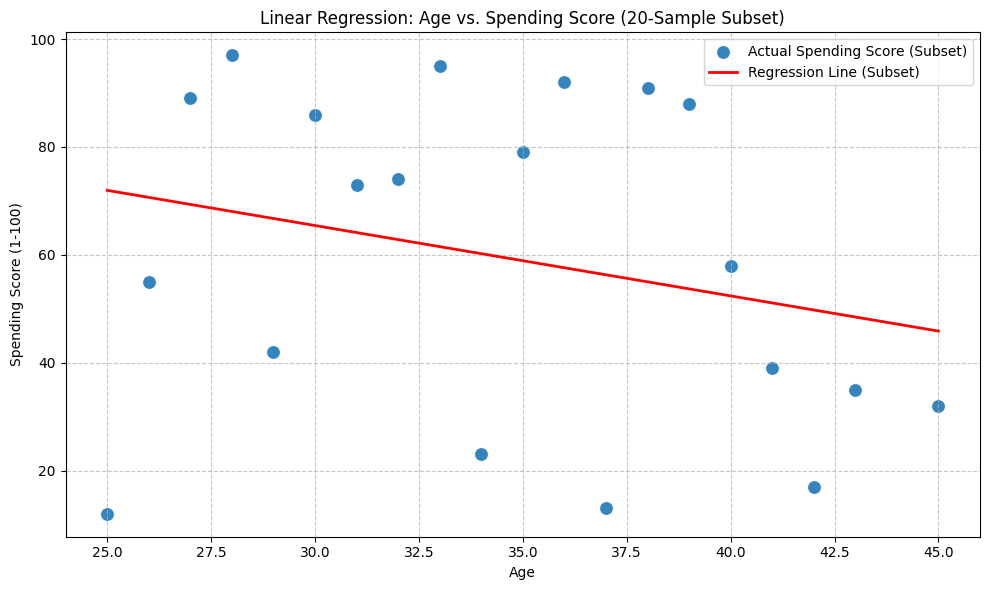

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual Age vs. Spending Score for the subset
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_subset_age['Age'], y=y_subset, label='Actual Spending Score (Subset)', alpha=0.9, s=100) # Increased marker size

# Plot the regression line for the subset
sns.lineplot(x=X_subset_age['Age'], y=y_subset_pred, color='red', label='Regression Line (Subset)', linewidth=2)

plt.title('Linear Regression: Age vs. Spending Score (20-Sample Subset)') # Updated title
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Part 2 — The Bias–Variance Trade-off (Synthetic Data)

### Why change datasets here?

With the Mall Customers data we saw *that* test error can rise as complexity increases. To explain
*why*, we need two things real data cannot give us:

1. **The true underlying function.** With real data we never know what relationship generated
   Spending Score, so we cannot measure how far our model is from the truth.
2. **Many independent training sets.** We only ever collected one. But "variance" is precisely the
   question *how much would the fitted model change if we had collected a different sample?*

A synthetic dataset solves both: we choose the true function ourselves and can generate as many
fresh training sets from it as we like. Everything else stays the same — same kind of model
(polynomial regression), same complexity knob (degree), same squared-error metric.

#Bias-Variance trade off on a Synthetic Dataset

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# --------------------------------------------------
# 1. True function
# --------------------------------------------------

def true_function(x):
    return np.sin(2 * np.pi * x)

# Fixed test points for plotting the true function
x_test = np.linspace(-1, 1, 500)
y_true = true_function(x_test)

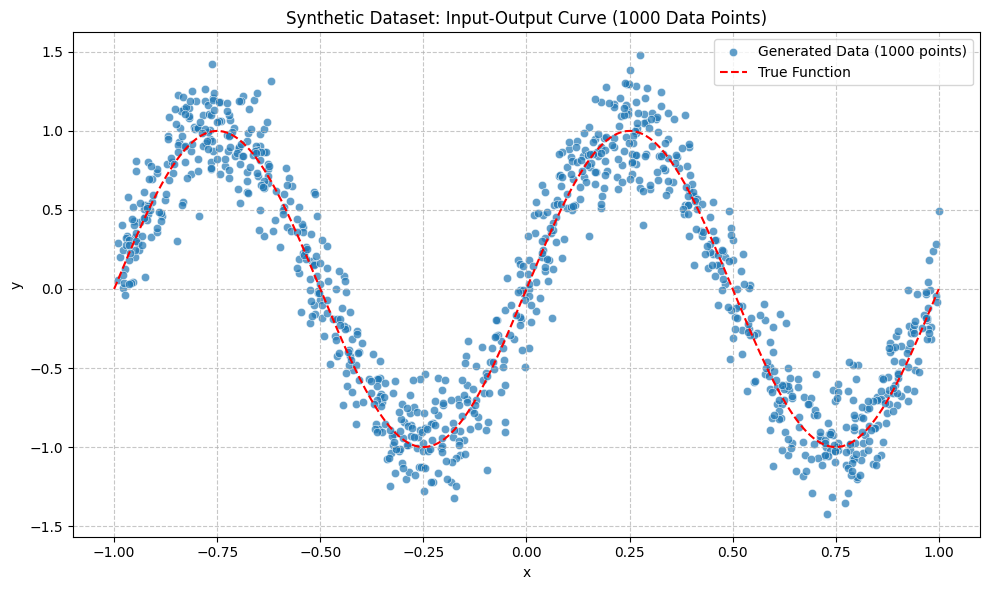

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

n_train_large = 1000
noise_std_large = 0.2

# Generate a large training dataset
x_train_large = np.random.uniform(-1, 1, n_train_large)
y_train_large = true_function(x_train_large) + np.random.normal(0, noise_std_large, n_train_large)
 
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_train_large, y=y_train_large, alpha=0.7, label='Generated Data (1000 points)')
plt.plot(x_test, y_true, color='red', linestyle='--', label='True Function')
plt.title('Synthetic Dataset: Input-Output Curve (1000 Data Points)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Fitting different complexities to one training sample

First, the same picture as in Part 1, but now the true function is drawn alongside the fit. We take
one small training sample and fit polynomials of several degrees to it.

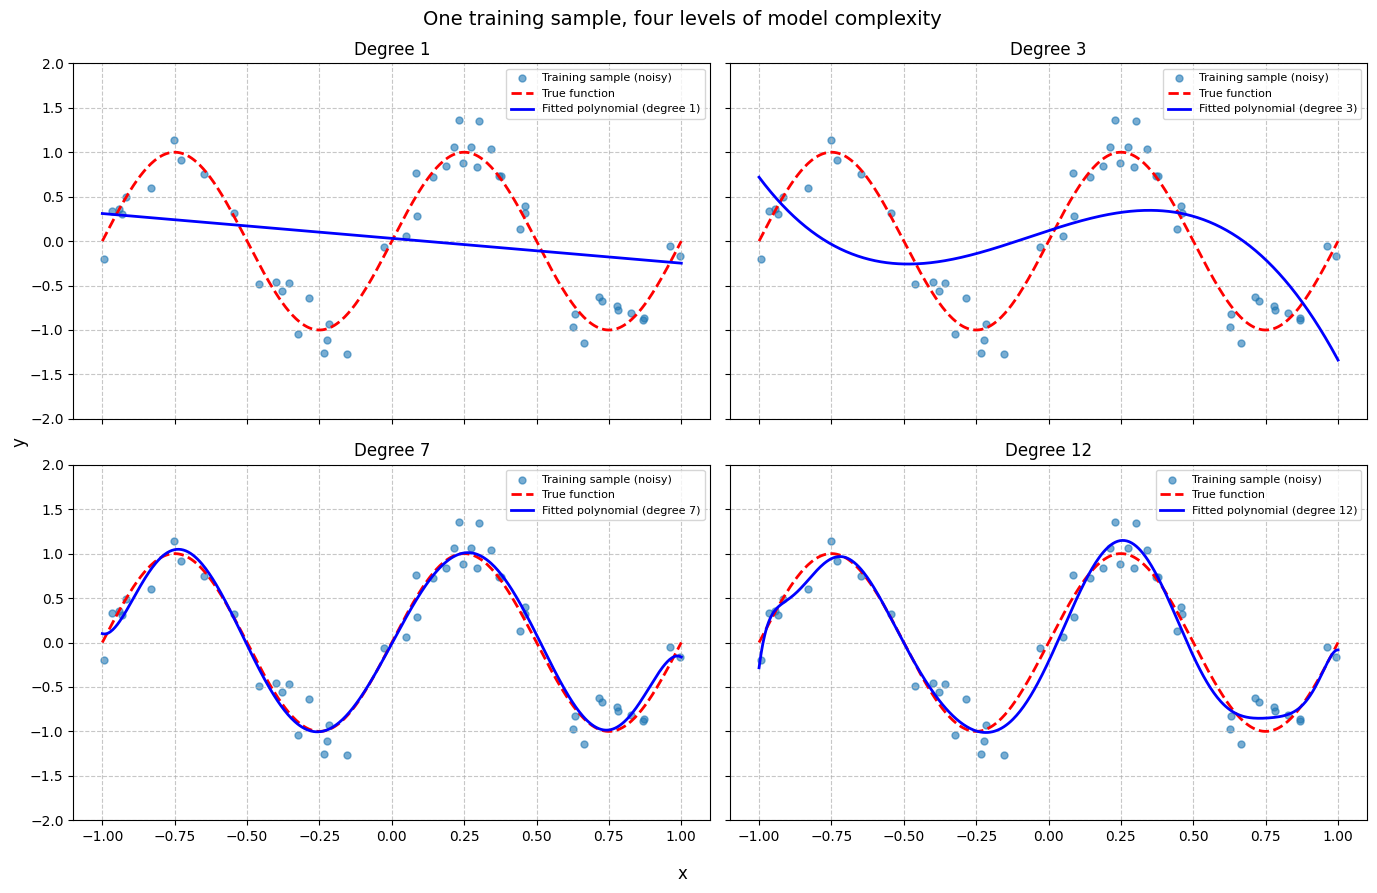

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

rng_demo = np.random.default_rng(0)

n_demo = 50          # points in this one training sample
noise_std = 0.2      # standard deviation of the noise, same as above

x_demo = rng_demo.uniform(-1, 1, n_demo)
y_demo = true_function(x_demo) + rng_demo.normal(0, noise_std, n_demo)

demo_degrees = [1, 3, 7, 12]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)

for ax, degree in zip(axes.ravel(), demo_degrees):
    model_demo = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model_demo.fit(x_demo.reshape(-1, 1), y_demo)
    y_fit = model_demo.predict(x_test.reshape(-1, 1))

    ax.scatter(x_demo, y_demo, alpha=0.6, s=25, label='Training sample (noisy)')
    ax.plot(x_test, y_true, color='red', linestyle='--', linewidth=2, label='True function')
    ax.plot(x_test, y_fit, color='blue', linewidth=2, label=f'Fitted polynomial (degree {degree})')
    ax.set_title(f'Degree {degree}')
    ax.set_ylim(-2, 2)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=8, loc='upper right')

fig.supxlabel('x')
fig.supylabel('y')
fig.suptitle('One training sample, four levels of model complexity', fontsize=14)
plt.tight_layout()
plt.show()

Reading the four panels:

* **Degree 1 — far too rigid.** Over $[-1, 1]$ the true function completes two full periods, and a
  straight line cannot follow any of it. Notice the *kind* of error this produces: the fit is wrong
  in the same direction at the same $x$ values, and it would be wrong in the same way for any
  training sample we drew. Systematic error of this sort is **bias**.
* **Degree 3 — still underfitting.** A cubic can bend, but it has nowhere near enough turning points
  for two periods of a sine. The bias is smaller than for the line, but not by much.
* **Degree 7 — a good fit.** Enough flexibility to track the true function across the whole interval.
* **Degree 12 — more flexible than necessary.** On *this* sample the curve looks fine, which is the
  important catch: **you cannot see variance in a single plot.** The extra flexibility does not
  necessarily produce a visibly crazy curve here; it produces a curve that would look *different* if
  we had drawn a different sample.

That last point is why we need many training sets, not one.

### A first look: repeating the fit on several subsets

The cells below train models of one fixed degree on 5 different subsets drawn from the large pool of
1000 points, and compute $\text{Bias}^2$ and Variance for each degree.

Two caveats to keep in mind while reading their numbers:

1. The 5 subsets are drawn from the *same* pool of 1000 points, and each takes 300 of them. Any two
   subsets therefore overlap heavily, which makes the fitted models more similar to one another than
   they should be. The measured variance is an **underestimate**.
2. With only 5 datasets, both estimates are themselves noisy.

We keep these cells because they show the mechanics clearly, and then redo the measurement properly
with fully independent training sets.

Training on subset 1/5...
  Model 1 Parameters:
    Intercept (w0): 0.0607
Training on subset 2/5...
  Model 2 Parameters:
    Intercept (w0): 0.0016
Training on subset 3/5...
  Model 3 Parameters:
    Intercept (w0): 0.0318
Training on subset 4/5...
  Model 4 Parameters:
    Intercept (w0): 0.0078
Training on subset 5/5...
  Model 5 Parameters:
    Intercept (w0): -0.0156

--- Bias-Variance Decomposition for 0th Order Function ---
Number of subsets: 5
Samples per subset: 300
Bias^2: 0.4993
Variance: 0.0007
Test Error: 0.5000
Bias^2 + Variance (Approx): 0.5000


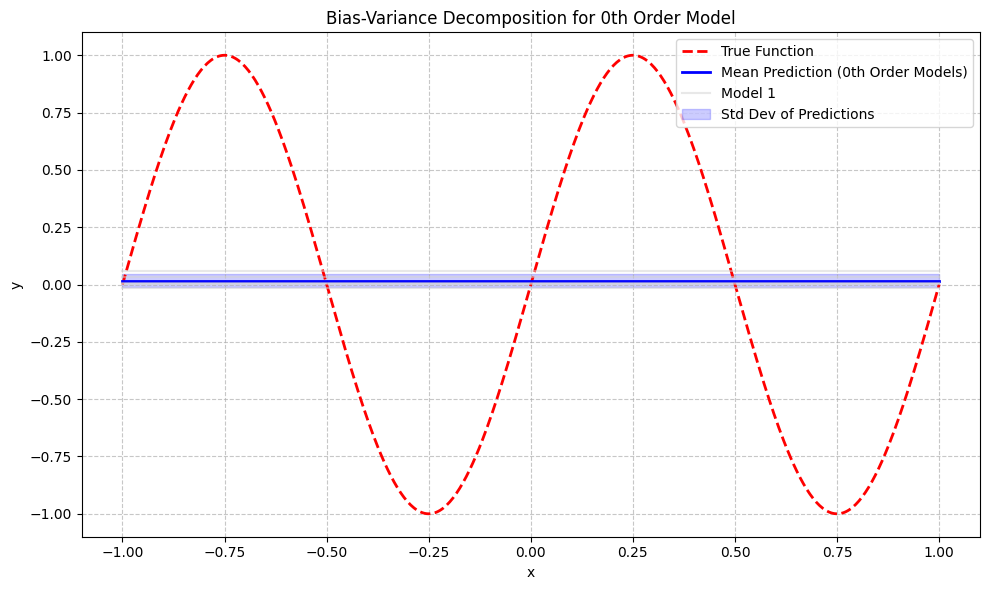

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Set random seed for reproducibility
np.random.seed(42)

# 1. Define the true function (already defined globally as true_function)
# and fixed test points (already defined globally as x_test, y_true)
# true_function(x) is np.sin(2 * np.pi * x)
# x_test = np.linspace(-1, 1, 500)
# y_true = true_function(x_test)

# 2. Experimental settings for bias-variance decomposition
n_train_bv = 300         # number of training examples in each subset
n_datasets_bv = 5        # number of different random training datasets (subsets)

# Store predictions from each model
predictions_bv = []

# Train the 0th order model on many different subsets
for i in range(n_datasets_bv):
    print(f"Training on subset {i+1}/{n_datasets_bv}...")
    # Generate a new training dataset by sampling from x_train_large
    indices = np.random.choice(len(x_train_large), n_train_bv, replace=False)
    x_train_bv = x_train_large[indices]
    y_train_bv = y_train_large[indices]

    # 0th order regression model (constant model)
    model_bv = make_pipeline(
        PolynomialFeatures(degree=0), # Degree 0 for constant model
        LinearRegression()
    )

    model_bv.fit(x_train_bv.reshape(-1, 1), y_train_bv)

    intercept = model_bv.named_steps['linearregression'].intercept_
    print(f"  Model {i+1} Parameters:")
    print(f"    Intercept (w0): {intercept:.4f}")

    # Prediction on the same fixed test points (global x_test)
    y_pred_bv = model_bv.predict(x_test.reshape(-1, 1))
    predictions_bv.append(y_pred_bv)


# 3. Calculate Bias, Variance and Test Error

# Average prediction over all training datasets
mean_prediction_bv = np.mean(predictions_bv, axis=0)

# Bias^2
bias_squared_bv_0 = np.mean(
    (mean_prediction_bv - y_true) ** 2
)

# Variance
variance_bv_0 = np.mean(
    np.var(predictions_bv, axis=0)
)

# Expected test error (MSE)
test_error_bv_0 = np.mean(
    (predictions_bv - y_true) ** 2
)

print(f"\n--- Bias-Variance Decomposition for 0th Order Function ---")
print(f"Number of subsets: {n_datasets_bv}")
print(f"Samples per subset: {n_train_bv}")
print(f"Bias^2: {bias_squared_bv_0:.4f}")
print(f"Variance: {variance_bv_0:.4f}")
print(f"Test Error: {test_error_bv_0:.4f}")
print(f"Bias^2 + Variance (Approx): {(bias_squared_bv_0 + variance_bv_0):.4f}")

# Optionally, visualize the results
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true, color='red', linestyle='--', label='True Function', linewidth=2)
plt.plot(x_test, mean_prediction_bv, color='blue', label='Mean Prediction (0th Order Models)', linewidth=2)

# Plot the individual model predictions for visualization
for i in range(n_datasets_bv):
    plt.plot(x_test, predictions_bv[i], color='lightgray', linestyle='-', alpha=0.5, label=f'Model {i+1}' if i==0 else "")

plt.fill_between(
    x_test,
    mean_prediction_bv - np.sqrt(np.var(predictions_bv, axis=0)),
    mean_prediction_bv + np.sqrt(np.var(predictions_bv, axis=0)),
    color='blue', alpha=0.2, label='Std Dev of Predictions'
)

plt.title('Bias-Variance Decomposition for 0th Order Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Training 1st Order Models for Bias-Variance Decomposition ---

Training on subset 1/5...
  Model 1 Parameters:
    Intercept (w0): 0.0073
    Coefficient (w1): 0.0000
    Estimated Variance (Training MSE): 0.4480

Training on subset 2/5...
  Model 2 Parameters:
    Intercept (w0): -0.0167
    Coefficient (w1): 0.0000
    Estimated Variance (Training MSE): 0.4665

Training on subset 3/5...
  Model 3 Parameters:
    Intercept (w0): -0.0003
    Coefficient (w1): 0.0000
    Estimated Variance (Training MSE): 0.4899

Training on subset 4/5...
  Model 4 Parameters:
    Intercept (w0): 0.0062
    Coefficient (w1): 0.0000
    Estimated Variance (Training MSE): 0.4531

Training on subset 5/5...
  Model 5 Parameters:
    Intercept (w0): -0.0021
    Coefficient (w1): 0.0000
    Estimated Variance (Training MSE): 0.4458

--- Bias-Variance Decomposition for 1st Order Function ---
Number of subsets: 5
Samples per subset: 300
Bias^2: 0.4245
Variance: 0.0011
Test Error: 0.4255
Bias^2 + Variance (A

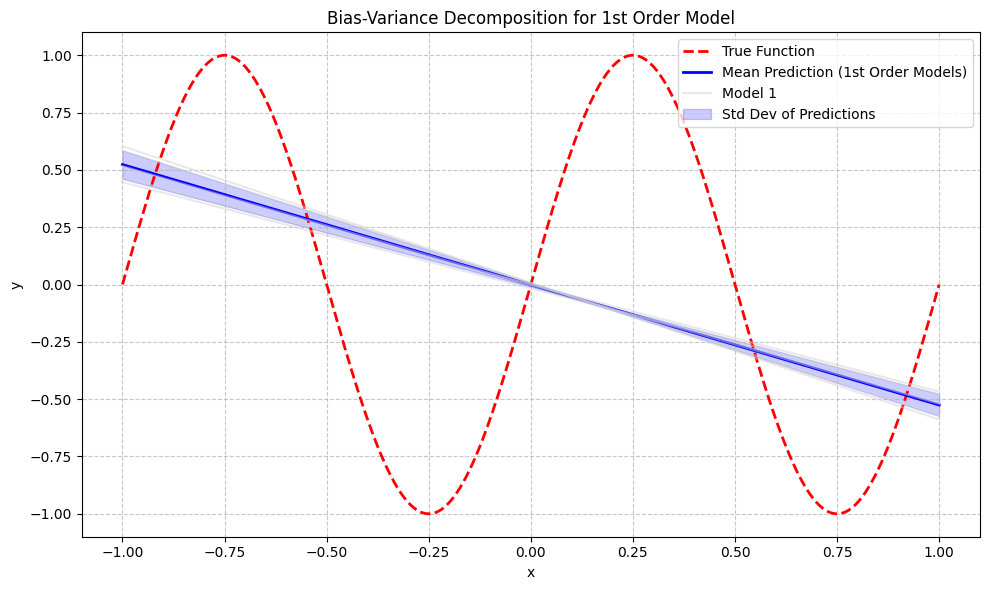

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error # Import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Global variables true_function, x_test, y_true, x_train_large, y_train_large
# are assumed to be available from previous cells as per context.

# 2. Experimental settings for bias-variance decomposition
n_train_bv = 300         # number of training examples in each subset
n_datasets_bv = 5        # number of different random training datasets (subsets)

# Store predictions from each model
predictions_bv = []

print(f"--- Training 1st Order Models for Bias-Variance Decomposition ---")
# Train the 1st order model on many different subsets
for i in range(n_datasets_bv):
    print(f"\nTraining on subset {i+1}/{n_datasets_bv}...")
    # Generate a new training dataset by sampling from x_train_large
    indices = np.random.choice(len(x_train_large), n_train_bv, replace=False)
    x_train_bv = x_train_large[indices]
    y_train_bv = y_train_large[indices]

    # 1st order regression model (linear model)
    model_bv = make_pipeline(
        PolynomialFeatures(degree=1), # Degree 1 for linear model
        LinearRegression()
    )

    model_bv.fit(x_train_bv.reshape(-1, 1), y_train_bv)

    # Extract parameters
    intercept = model_bv.named_steps['linearregression'].intercept_
    coef = model_bv.named_steps['linearregression'].coef_

    # Calculate training MSE as an estimate of noise variance
    y_train_pred_bv = model_bv.predict(x_train_bv.reshape(-1, 1))
    training_mse = mean_squared_error(y_train_bv, y_train_pred_bv)

    print(f"  Model {i+1} Parameters:")
    print(f"    Intercept (w0): {intercept:.4f}")
    if len(coef) > 0:
        print(f"    Coefficient (w1): {coef[0]:.4f}")
    print(f"    Estimated Variance (Training MSE): {training_mse:.4f}")

    # Prediction on the same fixed test points (global x_test)
    y_pred_bv = model_bv.predict(x_test.reshape(-1, 1))
    predictions_bv.append(y_pred_bv)

predictions_bv = np.array(predictions_bv)

# 3. Calculate Bias, Variance and Test Error

# Average prediction over all training datasets
mean_prediction_bv = np.mean(predictions_bv, axis=0)

# Bias^2
bias_squared_bv_1 = np.mean(
    (mean_prediction_bv - y_true) ** 2
)

# Variance
variance_bv_1 = np.mean(
    np.var(predictions_bv, axis=0)
)

# Expected test error (MSE)
test_error_bv_1 = np.mean(
    (predictions_bv - y_true) ** 2
)


print(f"\n--- Bias-Variance Decomposition for 1st Order Function ---")
print(f"Number of subsets: {n_datasets_bv}")
print(f"Samples per subset: {n_train_bv}")
print(f"Bias^2: {bias_squared_bv_1:.4f}")
print(f"Variance: {variance_bv_1:.4f}")
print(f"Test Error: {test_error_bv_1:.4f}")
print(f"Bias^2 + Variance (Approx): {(bias_squared_bv_1 + variance_bv_1):.4f}")

# Optionally, visualize the results
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true, color='red', linestyle='--', label='True Function', linewidth=2)
plt.plot(x_test, mean_prediction_bv, color='blue', label='Mean Prediction (1st Order Models)', linewidth=2)

# Plot the individual model predictions for visualization
for i in range(n_datasets_bv):
    plt.plot(x_test, predictions_bv[i], color='lightgray', linestyle='-', alpha=0.5, label=f'Model {i+1}' if i==0 else "")

plt.fill_between(
    x_test,
    mean_prediction_bv - np.sqrt(np.var(predictions_bv, axis=0)),
    mean_prediction_bv + np.sqrt(np.var(predictions_bv, axis=0)),
    color='blue', alpha=0.2, label='Std Dev of Predictions'
)

plt.title('Bias-Variance Decomposition for 1st Order Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Training 3rd Order Models for Bias-Variance Decomposition ---

Training on subset 1/5...
  Model 1 Parameters:
    Intercept (w0): 0.0062
    Coefficient (w1): 0.5417
    Coefficient (w2): -0.0369
    Coefficient (w3): -1.9008
    Estimated Variance (Training MSE): 0.3733

Training on subset 2/5...
  Model 2 Parameters:
    Intercept (w0): -0.0105
    Coefficient (w1): 0.5631
    Coefficient (w2): -0.0277
    Coefficient (w3): -1.6722
    Estimated Variance (Training MSE): 0.3993

Training on subset 3/5...
  Model 3 Parameters:
    Intercept (w0): 0.0020
    Coefficient (w1): 0.5937
    Coefficient (w2): 0.0338
    Coefficient (w3): -1.6793
    Estimated Variance (Training MSE): 0.4215

Training on subset 4/5...
  Model 4 Parameters:
    Intercept (w0): 0.0400
    Coefficient (w1): 0.5184
    Coefficient (w2): -0.1287
    Coefficient (w3): -1.8936
    Estimated Variance (Training MSE): 0.3796

Training on subset 5/5...
  Model 5 Parameters:
    Intercept (w0): 0.0060
    Coefficien

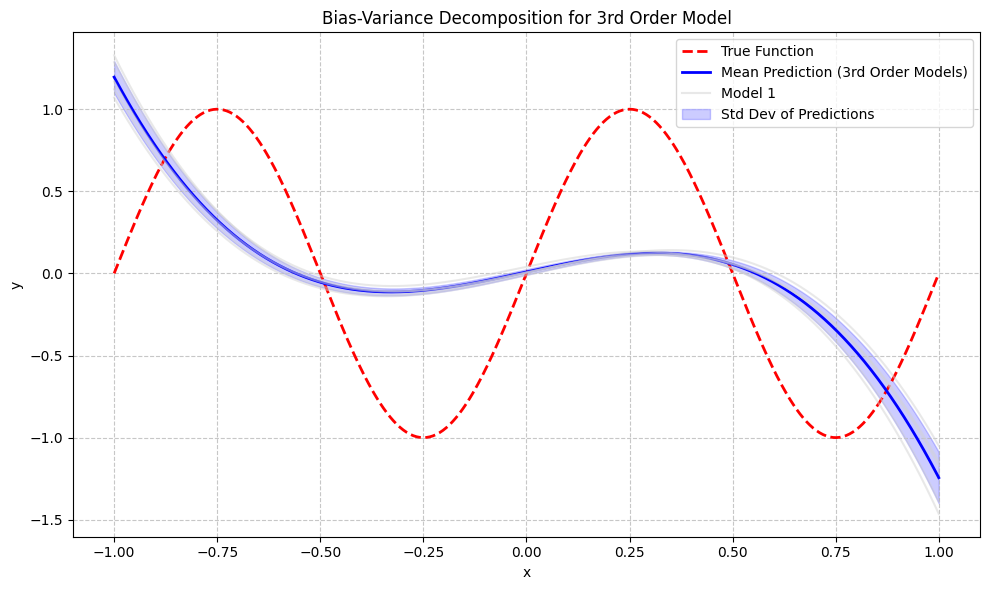

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error # Import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Global variables true_function, x_test, y_true, x_train_large, y_train_large
# are assumed to be available from previous cells as per context.

# 2. Experimental settings for bias-variance decomposition
n_train_bv = 300         # number of training examples in each subset
n_datasets_bv = 5        # number of different random training datasets (subsets)

# Store predictions from each model
predictions_bv = []

print(f"--- Training 3rd Order Models for Bias-Variance Decomposition ---")
# Train the 3rd order model on many different subsets
for i in range(n_datasets_bv):
    print(f"\nTraining on subset {i+1}/{n_datasets_bv}...")
    # Generate a new training dataset by sampling from x_train_large
    indices = np.random.choice(len(x_train_large), n_train_bv, replace=False)
    x_train_bv = x_train_large[indices]
    y_train_bv = y_train_large[indices]

    # 3rd order regression model
    model_bv = make_pipeline(
        PolynomialFeatures(degree=3), # Degree 3 for cubic model
        LinearRegression()
    )

    model_bv.fit(x_train_bv.reshape(-1, 1), y_train_bv)

    # Extract parameters
    intercept = model_bv.named_steps['linearregression'].intercept_
    coef = model_bv.named_steps['linearregression'].coef_

    # Calculate training MSE as an estimate of noise variance
    y_train_pred_bv = model_bv.predict(x_train_bv.reshape(-1, 1))
    training_mse = mean_squared_error(y_train_bv, y_train_pred_bv)

    print(f"  Model {i+1} Parameters:")
    print(f"    Intercept (w0): {intercept:.4f}")
    # Coefficients will be w1, w2, w3 for a 3rd order polynomial
    if len(coef) > 0:
        for j, c in enumerate(coef[1:]):
            print(f"    Coefficient (w{j+1}): {c:.4f}")
    print(f"    Estimated Variance (Training MSE): {training_mse:.4f}")

    # Prediction on the same fixed test points (global x_test)
    y_pred_bv = model_bv.predict(x_test.reshape(-1, 1))
    predictions_bv.append(y_pred_bv)

predictions_bv = np.array(predictions_bv)

# 3. Calculate Bias, Variance and Test Error

# Average prediction over all training datasets
mean_prediction_bv = np.mean(predictions_bv, axis=0)

# Bias^2
bias_squared_bv_3 = np.mean(
    (mean_prediction_bv - y_true) ** 2
)

# Variance
variance_bv_3 = np.mean(
    np.var(predictions_bv, axis=0)
)

# Expected test error (MSE)
test_error_bv_3 = np.mean(
    (predictions_bv - y_true) ** 2
)


print(f"\n--- Bias-Variance Decomposition for 3rd Order Function ---")
print(f"Number of subsets: {n_datasets_bv}")
print(f"Samples per subset: {n_train_bv}")
print(f"Bias^2: {bias_squared_bv_3:.4f}")
print(f"Variance: {variance_bv_3:.4f}")
print(f"Test Error: {test_error_bv_3:.4f}")
print(f"Bias^2 + Variance (Approx): {(bias_squared_bv_3 + variance_bv_3):.4f}")

# Optionally, visualize the results
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true, color='red', linestyle='--', label='True Function', linewidth=2)
plt.plot(x_test, mean_prediction_bv, color='blue', label='Mean Prediction (3rd Order Models)', linewidth=2)

# Plot the individual model predictions for visualization
for i in range(n_datasets_bv):
    plt.plot(x_test, predictions_bv[i], color='lightgray', linestyle='-', alpha=0.5, label=f'Model {i+1}' if i==0 else "")

plt.fill_between(
    x_test,
    mean_prediction_bv - np.sqrt(np.var(predictions_bv, axis=0)),
    mean_prediction_bv + np.sqrt(np.var(predictions_bv, axis=0)),
    color='blue', alpha=0.2, label='Std Dev of Predictions'
)

plt.title('Bias-Variance Decomposition for 3rd Order Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Training 10th Order Models for Bias-Variance Decomposition ---

Training on subset 1/5...
  Model 1 Parameters:
    Intercept (w0): 0.0436
    Coefficient (w1): 6.2244
    Coefficient (w2): 0.0654
    Coefficient (w3): -42.1602
    Coefficient (w4): -4.0540
    Coefficient (w5): 84.8697
    Coefficient (w6): 15.4804
    Coefficient (w7): -74.2904
    Coefficient (w8): -19.5087
    Coefficient (w9): 25.5234
    Coefficient (w10): 7.8868
    Estimated Variance (Training MSE): 0.0390

Training on subset 2/5...
  Model 2 Parameters:
    Intercept (w0): 0.0126
    Coefficient (w1): 6.0833
    Coefficient (w2): -0.0147
    Coefficient (w3): -38.5466
    Coefficient (w4): 0.8714
    Coefficient (w5): 68.6066
    Coefficient (w6): -4.5388
    Coefficient (w7): -49.1100
    Coefficient (w8): 6.7363
    Coefficient (w9): 12.9683
    Coefficient (w10): -2.9611
    Estimated Variance (Training MSE): 0.0392

Training on subset 3/5...
  Model 3 Parameters:
    Intercept (w0): -0.0118
    Coeffic

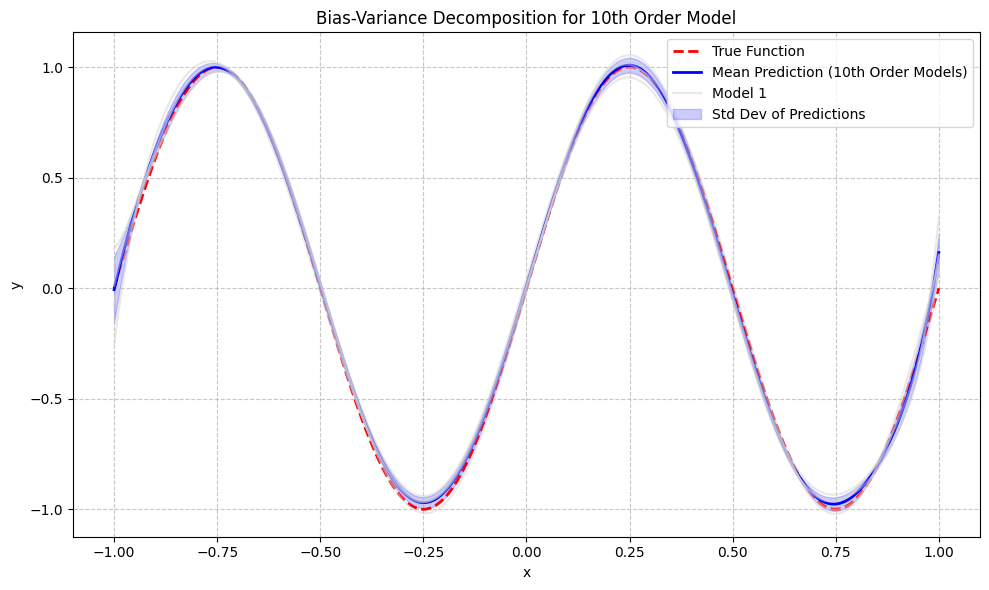

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error # Import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Global variables true_function, x_test, y_true, x_train_large, y_train_large
# are assumed to be available from previous cells as per context.

# 2. Experimental settings for bias-variance decomposition
n_train_bv = 300         # number of training examples in each subset
n_datasets_bv = 5        # number of different random training datasets (subsets)

# Store predictions from each model
predictions_bv = []

print(f"--- Training 10th Order Models for Bias-Variance Decomposition ---")
# Train the 10th order model on many different subsets
for i in range(n_datasets_bv):
    print(f"\nTraining on subset {i+1}/{n_datasets_bv}...")
    # Generate a new training dataset by sampling from x_train_large
    indices = np.random.choice(len(x_train_large), n_train_bv, replace=False)
    x_train_bv = x_train_large[indices]
    y_train_bv = y_train_large[indices]

    # 10th order regression model
    model_bv = make_pipeline(
        PolynomialFeatures(degree=10), # Degree 10 for higher order polynomial
        LinearRegression()
    )

    model_bv.fit(x_train_bv.reshape(-1, 1), y_train_bv)

    # Extract parameters
    intercept = model_bv.named_steps['linearregression'].intercept_
    coef = model_bv.named_steps['linearregression'].coef_

    # Calculate training MSE as an estimate of noise variance
    y_train_pred_bv = model_bv.predict(x_train_bv.reshape(-1, 1))
    training_mse = mean_squared_error(y_train_bv, y_train_pred_bv)

    print(f"  Model {i+1} Parameters:")
    print(f"    Intercept (w0): {intercept:.4f}")
    # Coefficients will be w1 to w10 for a 10th order polynomial
    if len(coef) > 0:
        for j, c in enumerate(coef[1:]):
            print(f"    Coefficient (w{j+1}): {c:.4f}")
    print(f"    Estimated Variance (Training MSE): {training_mse:.4f}")

    # Prediction on the same fixed test points (global x_test)
    y_pred_bv = model_bv.predict(x_test.reshape(-1, 1))
    predictions_bv.append(y_pred_bv)

predictions_bv = np.array(predictions_bv)

# 3. Calculate Bias, Variance and Test Error

# Average prediction over all training datasets
mean_prediction_bv = np.mean(predictions_bv, axis=0)

# Bias^2
bias_squared_bv_10 = np.mean(
    (mean_prediction_bv - y_true) ** 2
)

# Variance
variance_bv_10 = np.mean(
    np.var(predictions_bv, axis=0)
)

# Expected test error (MSE)
test_error_bv_10 = np.mean(
    (predictions_bv - y_true) ** 2
)


print(f"\n--- Bias-Variance Decomposition for 10th Order Function ---")
print(f"Number of subsets: {n_datasets_bv}")
print(f"Samples per subset: {n_train_bv}")
print(f"Bias^2: {bias_squared_bv_10:.4f}")
print(f"Variance: {variance_bv_10:.4f}")
print(f"Test Error: {test_error_bv_10:.4f}")
print(f"Bias^2 + Variance (Approx): {(bias_squared_bv_10 + variance_bv_10):.4f}")

# Optionally, visualize the results
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true, color='red', linestyle='--', label='True Function', linewidth=2)
plt.plot(x_test, mean_prediction_bv, color='blue', label='Mean Prediction (10th Order Models)', linewidth=2)

# Plot the individual model predictions for visualization
for i in range(n_datasets_bv):
    plt.plot(x_test, predictions_bv[i], color='lightgray', linestyle='-', alpha=0.5, label=f'Model {i+1}' if i==0 else "")

plt.fill_between(
    x_test,
    mean_prediction_bv - np.sqrt(np.var(predictions_bv, axis=0)),
    mean_prediction_bv + np.sqrt(np.var(predictions_bv, axis=0)),
    color='blue', alpha=0.2, label='Std Dev of Predictions'
)

plt.title('Bias-Variance Decomposition for 10th Order Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Training 15th Order Models for Bias-Variance Decomposition ---

Training on subset 1/5...
  Model 1 Parameters:
    Intercept (w0): 0.0593
    Coefficient (w1): 6.2299
    Coefficient (w2): -0.8404
    Coefficient (w3): -37.3345
    Coefficient (w4): 4.9995
    Coefficient (w5): -7.4614
    Coefficient (w6): -9.7997
    Coefficient (w7): 503.9394
    Coefficient (w8): -20.7561
    Coefficient (w9): -1644.4789
    Coefficient (w10): 107.7026
    Coefficient (w11): 2452.9312
    Coefficient (w12): -139.2065
    Coefficient (w13): -1782.4505
    Coefficient (w14): 57.9691
    Coefficient (w15): 508.9236
    Estimated Variance (Training MSE): 0.0381

Training on subset 2/5...
  Model 2 Parameters:
    Intercept (w0): -0.0012
    Coefficient (w1): 6.1860
    Coefficient (w2): 1.4570
    Coefficient (w3): -36.3320
    Coefficient (w4): -27.8451
    Coefficient (w5): -4.5258
    Coefficient (w6): 197.7587
    Coefficient (w7): 475.7602
    Coefficient (w8): -654.4699
    Coefficient (w9):

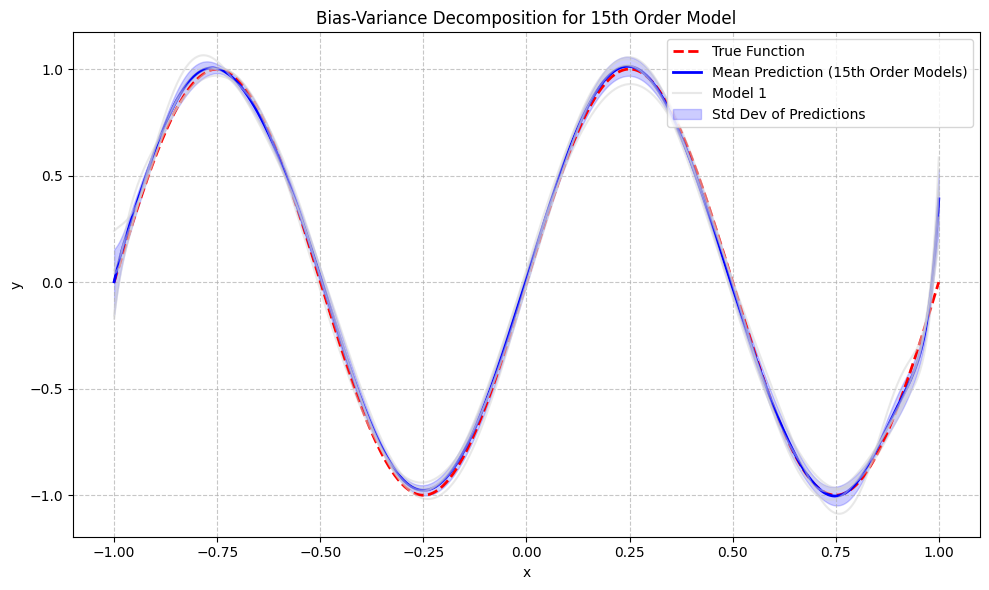

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error # Import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Global variables true_function, x_test, y_true, x_train_large, y_train_large
# are assumed to be available from previous cells as per context.

# 2. Experimental settings for bias-variance decomposition
n_train_bv = 300         # number of training examples in each subset
n_datasets_bv = 5        # number of different random training datasets (subsets)

# Store predictions from each model
predictions_bv = []

print(f"--- Training 15th Order Models for Bias-Variance Decomposition ---")
# Train the 15th order model on many different subsets
for i in range(n_datasets_bv):
    print(f"\nTraining on subset {i+1}/{n_datasets_bv}...")
    # Generate a new training dataset by sampling from x_train_large
    indices = np.random.choice(len(x_train_large), n_train_bv, replace=False)
    x_train_bv = x_train_large[indices]
    y_train_bv = y_train_large[indices]

    # 15th order regression model
    model_bv = make_pipeline(
        PolynomialFeatures(degree=15), # Degree 15 for higher order polynomial
        LinearRegression()
    )

    model_bv.fit(x_train_bv.reshape(-1, 1), y_train_bv)

    # Extract parameters
    intercept = model_bv.named_steps['linearregression'].intercept_
    coef = model_bv.named_steps['linearregression'].coef_

    # Calculate training MSE as an estimate of noise variance
    y_train_pred_bv = model_bv.predict(x_train_bv.reshape(-1, 1))
    training_mse = mean_squared_error(y_train_bv, y_train_pred_bv)

    print(f"  Model {i+1} Parameters:")
    print(f"    Intercept (w0): {intercept:.4f}")
    # Coefficients will be w1 to w15 for a 15th order polynomial
    if len(coef) > 0:
        for j, c in enumerate(coef[1:]):
            print(f"    Coefficient (w{j+1}): {c:.4f}")
    print(f"    Estimated Variance (Training MSE): {training_mse:.4f}")

    # Prediction on the same fixed test points (global x_test)
    y_pred_bv = model_bv.predict(x_test.reshape(-1, 1))
    predictions_bv.append(y_pred_bv)

predictions_bv = np.array(predictions_bv)

# 3. Calculate Bias, Variance and Test Error

# Average prediction over all training datasets
mean_prediction_bv = np.mean(predictions_bv, axis=0)

# Bias^2
bias_squared_bv_15 = np.mean(
    (mean_prediction_bv - y_true) ** 2
)

# Variance
variance_bv_15 = np.mean(
    np.var(predictions_bv, axis=0)
)

# Expected test error (MSE)
test_error_bv_15 = np.mean(
    (predictions_bv - y_true) ** 2
)


print(f"\n--- Bias-Variance Decomposition for 15th Order Function ---")
print(f"Number of subsets: {n_datasets_bv}")
print(f"Samples per subset: {n_train_bv}")
print(f"Bias^2: {bias_squared_bv_15:.4f}")
print(f"Variance: {variance_bv_15:.4f}")
print(f"Test Error: {test_error_bv_15:.4f}")
print(f"Bias^2 + Variance (Approx): {(bias_squared_bv_15 + variance_bv_15):.4f}")

# Optionally, visualize the results
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true, color='red', linestyle='--', label='True Function', linewidth=2)
plt.plot(x_test, mean_prediction_bv, color='blue', label='Mean Prediction (15th Order Models)', linewidth=2)

# Plot the individual model predictions for visualization
for i in range(n_datasets_bv):
    plt.plot(x_test, predictions_bv[i], color='lightgray', linestyle='-', alpha=0.5, label=f'Model {i+1}' if i==0 else "")

plt.fill_between(
    x_test,
    mean_prediction_bv - np.sqrt(np.var(predictions_bv, axis=0)),
    mean_prediction_bv + np.sqrt(np.var(predictions_bv, axis=0)),
    color='blue', alpha=0.2, label='Std Dev of Predictions'
)

plt.title('Bias-Variance Decomposition for 15th Order Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Training 20th Order Models for Bias-Variance Decomposition ---

Training on subset 1/5...
  Model 1 Parameters:
    Intercept (w0): 0.0255
    Coefficient (w1): 6.7508
    Coefficient (w2): 5.1549
    Coefficient (w3): -63.2262
    Coefficient (w4): -167.6399
    Coefficient (w5): 405.0208
    Coefficient (w6): 1978.0364
    Coefficient (w7): -2552.3451
    Coefficient (w8): -12023.1291
    Coefficient (w9): 10727.8997
    Coefficient (w10): 42928.9976
    Coefficient (w11): -27095.5857
    Coefficient (w12): -95384.1320
    Coefficient (w13): 40973.7371
    Coefficient (w14): 133745.1837
    Coefficient (w15): -36302.1075
    Coefficient (w16): -115175.0277
    Coefficient (w17): 17334.3808
    Coefficient (w18): 55615.4085
    Coefficient (w19): -3434.0029
    Coefficient (w20): -11523.5762
    Estimated Variance (Training MSE): 0.0376

Training on subset 2/5...
  Model 2 Parameters:
    Intercept (w0): 0.0162
    Coefficient (w1): 6.1029
    Coefficient (w2): -1.8933
    Coeffic

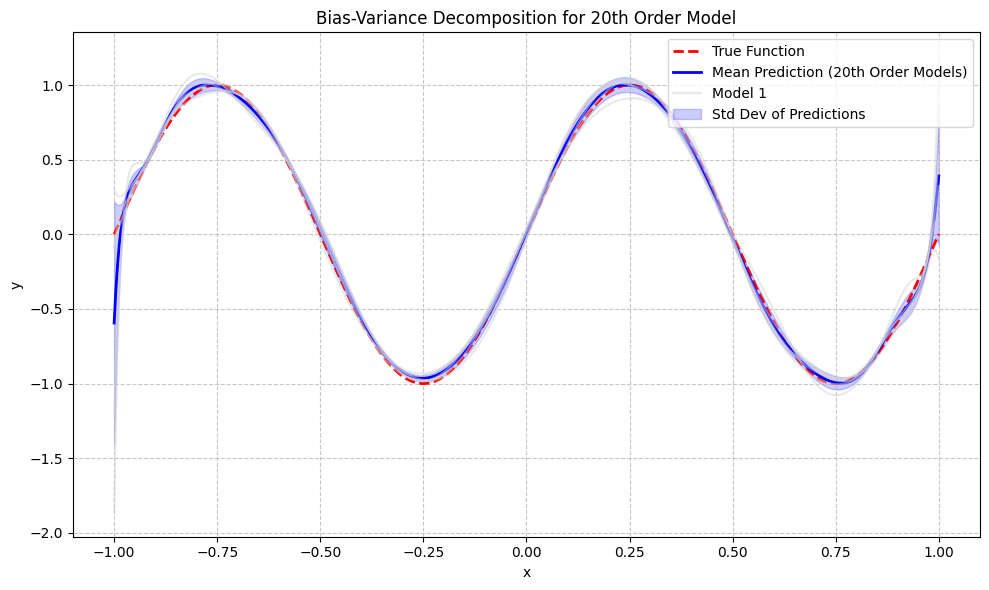

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error # Import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Global variables true_function, x_test, y_true, x_train_large, y_train_large
# are assumed to be available from previous cells as per context.

# 2. Experimental settings for bias-variance decomposition
n_train_bv = 300         # number of training examples in each subset
n_datasets_bv = 5        # number of different random training datasets (subsets)

# Store predictions from each model
predictions_bv = []

print(f"--- Training 20th Order Models for Bias-Variance Decomposition ---")
# Train the 20th order model on many different subsets
for i in range(n_datasets_bv):
    print(f"\nTraining on subset {i+1}/{n_datasets_bv}...")
    # Generate a new training dataset by sampling from x_train_large
    indices = np.random.choice(len(x_train_large), n_train_bv, replace=False)
    x_train_bv = x_train_large[indices]
    y_train_bv = y_train_large[indices]

    # 20th order regression model
    model_bv = make_pipeline(
        PolynomialFeatures(degree=20), # Degree 20 for higher order polynomial
        LinearRegression()
    )

    model_bv.fit(x_train_bv.reshape(-1, 1), y_train_bv)

    # Extract parameters
    intercept = model_bv.named_steps['linearregression'].intercept_
    coef = model_bv.named_steps['linearregression'].coef_

    # Calculate training MSE as an estimate of noise variance
    y_train_pred_bv = model_bv.predict(x_train_bv.reshape(-1, 1))
    training_mse = mean_squared_error(y_train_bv, y_train_pred_bv)

    print(f"  Model {i+1} Parameters:")
    print(f"    Intercept (w0): {intercept:.4f}")
    # Coefficients will be w1 to w15 for a 15th order polynomial
    if len(coef) > 0:
        for j, c in enumerate(coef[1:]):
            print(f"    Coefficient (w{j+1}): {c:.4f}")
    print(f"    Estimated Variance (Training MSE): {training_mse:.4f}")

    # Prediction on the same fixed test points (global x_test)
    y_pred_bv = model_bv.predict(x_test.reshape(-1, 1))
    predictions_bv.append(y_pred_bv)

predictions_bv = np.array(predictions_bv)

# 3. Calculate Bias, Variance and Test Error

# Average prediction over all training datasets
mean_prediction_bv = np.mean(predictions_bv, axis=0)

# Bias^2
bias_squared_bv_20 = np.mean(
    (mean_prediction_bv - y_true) ** 2
)

# Variance
variance_bv_20 = np.mean(
    np.var(predictions_bv, axis=0)
)

# Expected test error (MSE)
test_error_bv_20 = np.mean(
    (predictions_bv - y_true) ** 2
)


print(f"\n--- Bias-Variance Decomposition for 20th Order Function ---")
print(f"Number of subsets: {n_datasets_bv}")
print(f"Samples per subset: {n_train_bv}")
print(f"Bias^2: {bias_squared_bv_20:.4f}")
print(f"Variance: {variance_bv_20:.4f}")
print(f"Test Error: {test_error_bv_20:.4f}")
print(f"Bias^2 + Variance (Approx): {(bias_squared_bv_20 + variance_bv_20):.4f}")

# Optionally, visualize the results
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true, color='red', linestyle='--', label='True Function', linewidth=2)
plt.plot(x_test, mean_prediction_bv, color='blue', label='Mean Prediction (20th Order Models)', linewidth=2)

# Plot the individual model predictions for visualization
for i in range(n_datasets_bv):
    plt.plot(x_test, predictions_bv[i], color='lightgray', linestyle='-', alpha=0.5, label=f'Model {i+1}' if i==0 else "")

plt.fill_between(
    x_test,
    mean_prediction_bv - np.sqrt(np.var(predictions_bv, axis=0)),
    mean_prediction_bv + np.sqrt(np.var(predictions_bv, axis=0)),
    color='blue', alpha=0.2, label='Std Dev of Predictions'
)

plt.title('Bias-Variance Decomposition for 20th Order Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Training 25th Order Models for Bias-Variance Decomposition ---

Training on subset 1/5...
  Model 1 Parameters:
    Intercept (w0): -0.1139
    Coefficient (w1): 6.8242
    Coefficient (w2): 4.2176
    Coefficient (w3): -83.3245
    Coefficient (w4): -134.3841
    Coefficient (w5): 1278.3884
    Coefficient (w6): 1555.9021
    Coefficient (w7): -17682.9121
    Coefficient (w8): -9738.3963
    Coefficient (w9): 146740.8670
    Coefficient (w10): 39707.5718
    Coefficient (w11): -748786.4608
    Coefficient (w12): -118347.9955
    Coefficient (w13): 2465580.3124
    Coefficient (w14): 269839.1475
    Coefficient (w15): -5385484.5389
    Coefficient (w16): -460504.0963
    Coefficient (w17): 7860967.5125
    Coefficient (w18): 554552.4967
    Coefficient (w19): -7561254.8375
    Coefficient (w20): -435857.2649
    Coefficient (w21): 4586734.6758
    Coefficient (w22): 198261.2814
    Coefficient (w23): -1584760.2516
    Coefficient (w24): -39339.6610
    Coefficient (w25): 236741.274

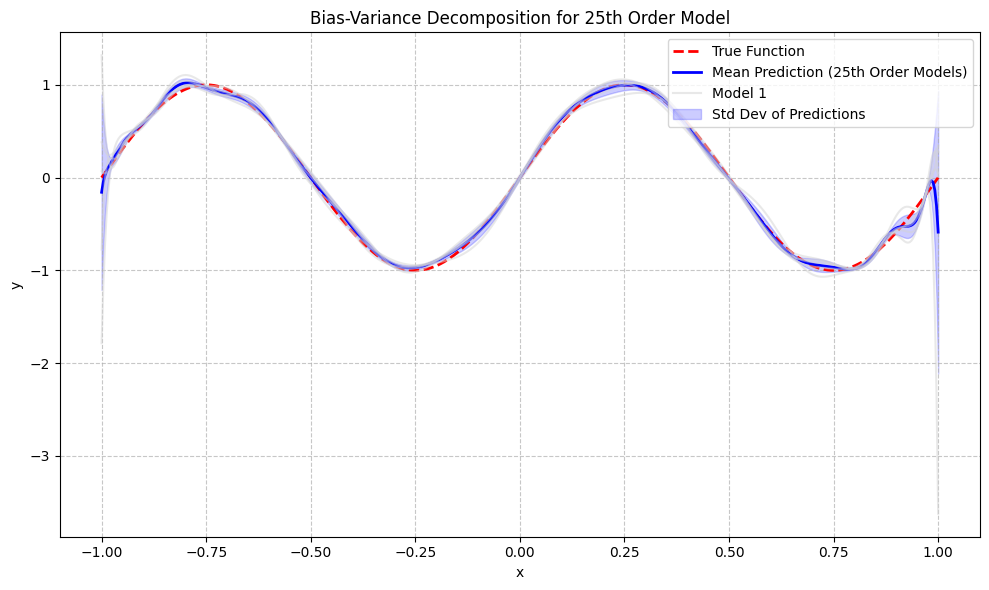

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error # Import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Global variables true_function, x_test, y_true, x_train_large, y_train_large
# are assumed to be available from previous cells as per context.

# 2. Experimental settings for bias-variance decomposition
n_train_bv = 300         # number of training examples in each subset
n_datasets_bv = 5        # number of different random training datasets (subsets)

# Store predictions from each model
predictions_bv = []

print(f"--- Training 25th Order Models for Bias-Variance Decomposition ---")
# Train the 25th order model on many different subsets
for i in range(n_datasets_bv):
    print(f"\nTraining on subset {i+1}/{n_datasets_bv}...")
    # Generate a new training dataset by sampling from x_train_large
    indices = np.random.choice(len(x_train_large), n_train_bv, replace=False)
    x_train_bv = x_train_large[indices]
    y_train_bv = y_train_large[indices]

    # 25th order regression model
    model_bv = make_pipeline(
        PolynomialFeatures(degree=25), # Degree 25 for higher order polynomial
        LinearRegression()
    )

    model_bv.fit(x_train_bv.reshape(-1, 1), y_train_bv)

    # Extract parameters
    intercept = model_bv.named_steps['linearregression'].intercept_
    coef = model_bv.named_steps['linearregression'].coef_

    # Calculate training MSE as an estimate of noise variance
    y_train_pred_bv = model_bv.predict(x_train_bv.reshape(-1, 1))
    training_mse = mean_squared_error(y_train_bv, y_train_pred_bv)

    print(f"  Model {i+1} Parameters:")
    print(f"    Intercept (w0): {intercept:.4f}")
    # Coefficients will be w1 to w25 for a 25th order polynomial
    if len(coef) > 0:
        for j, c in enumerate(coef[1:]):
            print(f"    Coefficient (w{j+1}): {c:.4f}")
    print(f"    Estimated Variance (Training MSE): {training_mse:.4f}")

    # Prediction on the same fixed test points (global x_test)
    y_pred_bv = model_bv.predict(x_test.reshape(-1, 1))
    predictions_bv.append(y_pred_bv)

predictions_bv = np.array(predictions_bv)

# 3. Calculate Bias, Variance and Test Error

# Average prediction over all training datasets
mean_prediction_bv = np.mean(predictions_bv, axis=0)

# Bias^2
bias_squared_bv_25 = np.mean(
    (mean_prediction_bv - y_true) ** 2
)

# Variance
variance_bv_25 = np.mean(
    np.var(predictions_bv, axis=0)
)

# Expected test error (MSE)
test_error_bv_25 = np.mean(
    (predictions_bv - y_true) ** 2
)


print(f"\n--- Bias-Variance Decomposition for 25th Order Function ---")
print(f"Number of subsets: {n_datasets_bv}")
print(f"Samples per subset: {n_train_bv}")
print(f"Bias^2: {bias_squared_bv_25:.4f}")
print(f"Variance: {variance_bv_25:.4f}")
print(f"Test Error: {test_error_bv_25:.4f}")
print(f"Bias^2 + Variance (Approx): {(bias_squared_bv_25 + variance_bv_25):.4f}")

# Optionally, visualize the results
plt.figure(figsize=(10, 6))
plt.plot(x_test, y_true, color='red', linestyle='--', label='True Function', linewidth=2)
plt.plot(x_test, mean_prediction_bv, color='blue', label='Mean Prediction (25th Order Models)', linewidth=2)

# Plot the individual model predictions for visualization
for i in range(n_datasets_bv):
    plt.plot(x_test, predictions_bv[i], color='lightgray', linestyle='-', alpha=0.5, label=f'Model {i+1}' if i==0 else "")

plt.fill_between(
    x_test,
    mean_prediction_bv - np.sqrt(np.var(predictions_bv, axis=0)),
    mean_prediction_bv + np.sqrt(np.var(predictions_bv, axis=0)),
    color='blue', alpha=0.2, label='Std Dev of Predictions'
)

plt.title('Bias-Variance Decomposition for 25th Order Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

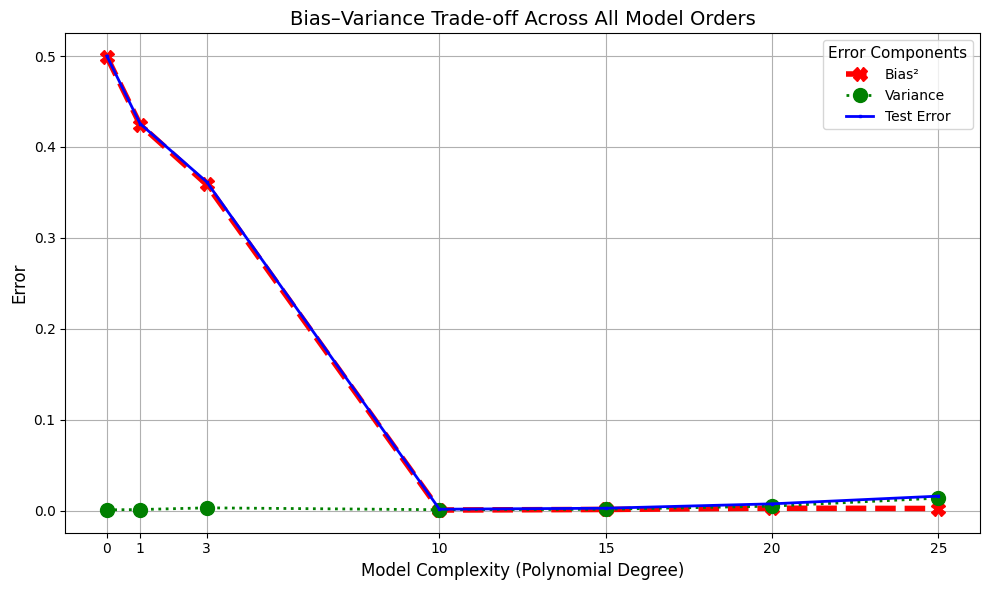

In [28]:
import matplotlib.pyplot as plt

# Assuming 'degrees', 'bias_squared', 'variance', and 'test_error' lists
# are available from the previous execution of the Bias-Variance trade-off cell (ya6hZ7iKv7J_).
# Updated to include degree 25
degrees = [0, 1, 3, 10, 15, 20, 25]
bias_squared = [bias_squared_bv_0, bias_squared_bv_1, bias_squared_bv_3, bias_squared_bv_10, bias_squared_bv_15, bias_squared_bv_20, bias_squared_bv_25]
variance = [variance_bv_0, variance_bv_1, variance_bv_3, variance_bv_10, variance_bv_15, variance_bv_20, variance_bv_25]
test_error = [test_error_bv_0, test_error_bv_1, test_error_bv_3, test_error_bv_10, test_error_bv_15, test_error_bv_20, test_error_bv_25]


plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    bias_squared,
    marker='X',
    label='Bias²',
    linewidth=4,
    color='red',
    markersize=10,
    linestyle='--'
)

plt.plot(
    degrees,
    variance,
    marker='o',
    label='Variance',
    linewidth=2,
    color='green',
    markersize=10,
    linestyle=':'
)

plt.plot(
    degrees,
    test_error,
    marker='s',
    label='Test Error',
    linewidth=2,
    color='blue',
    markersize=2,
    linestyle='-'
)

plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=12)
plt.ylabel("Error", fontsize=12)
plt.title("Bias–Variance Trade-off Across All Model Orders", fontsize=14)
plt.legend(title="Error Components", fontsize=10, title_fontsize='11') # Added legend title and adjusted title font size
plt.grid(True)
plt.xticks(degrees)
plt.tight_layout()
plt.show()

The plot above already shows the shape we are after: $\text{Bias}^2$ falls with complexity while
Variance rises. Two things about it are worth being precise about.

* The "Test Error" plotted here is measured against the **noise-free** true function, so by
  construction it equals $\text{Bias}^2 + \text{Variance}$ exactly, with no irreducible noise term.
  Test error measured against real (noisy) observations is larger by $\sigma^2$.
* As noted above, the variance is underestimated because the 5 training subsets overlap.

The next section repeats the experiment with fully independent training sets, more of them, and a
noise term included.

### Visualizing bias and variance directly

The experiment: generate many **independent** training datasets from the same data-generating
process

$$y = f(x) + \epsilon, \qquad f(x) = \sin(2\pi x), \qquad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

For each dataset, fit a polynomial of a given degree and predict on one common dense grid of
$x$ values. Then plot all the fitted curves on top of each other.

Read each panel like this:

* **How far is the *average* curve (blue) from the true function (red)?** → that gap is bias.
* **How widely do the individual grey curves spread around their average?** → that spread is variance.

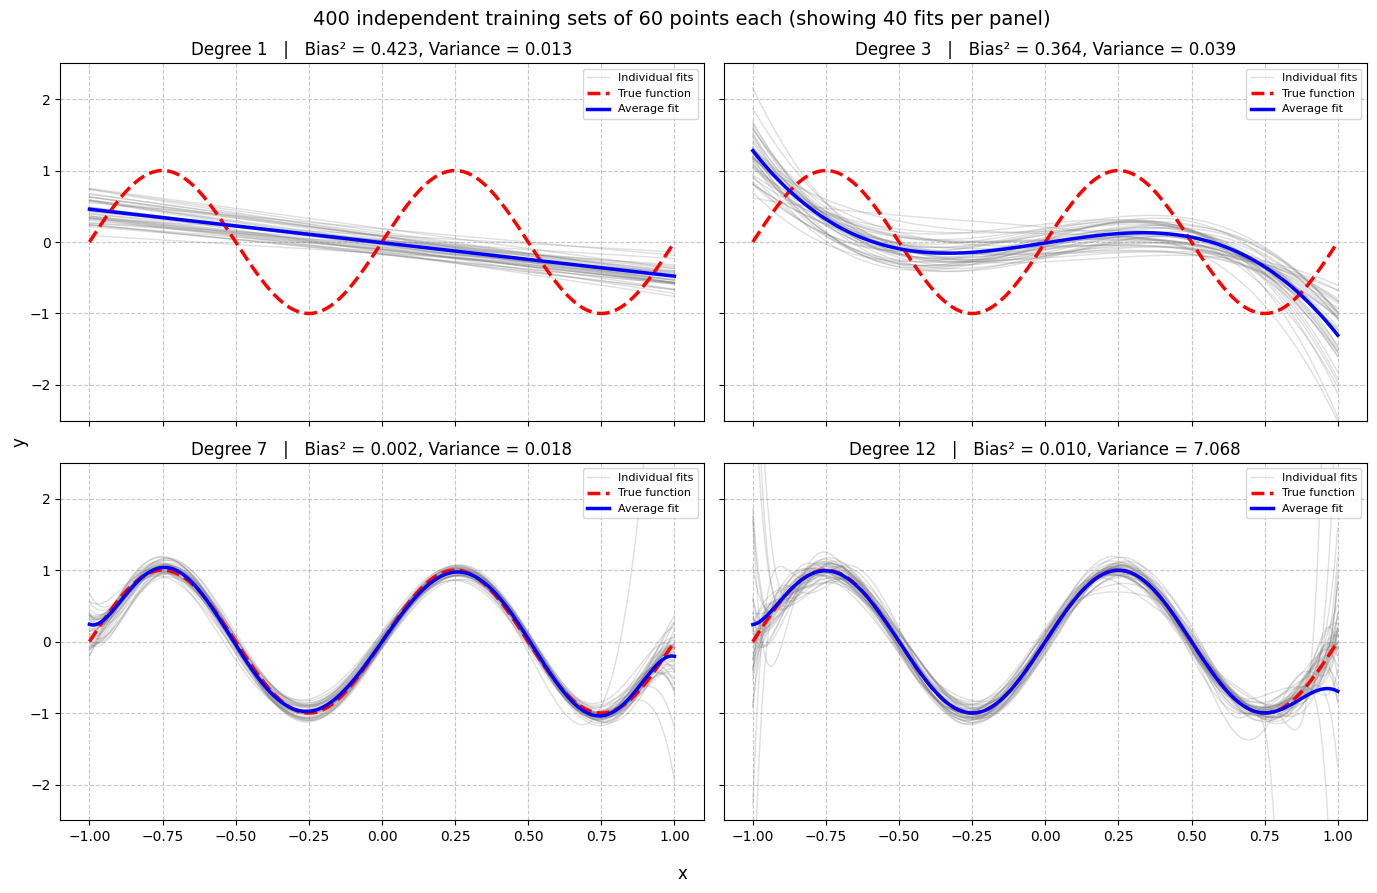

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# ---------------------------------------------------------------
# Experimental setup: independent training sets, common test grid
# ---------------------------------------------------------------
n_train_bv2 = 60        # points per training dataset
n_datasets_bv2 = 400    # number of independent training datasets
noise_std = 0.2         # sigma of the Gaussian noise

x_grid = np.linspace(-1, 1, 200)     # common dense grid
y_grid_true = true_function(x_grid)  # true function on that grid


def fit_predictions(degree, n_datasets=n_datasets_bv2, n_train=n_train_bv2, seed=0):
    '''Fit `n_datasets` models of the given degree, each on a fresh independent training set.

    Returns an array of shape (n_datasets, len(x_grid)) with the predictions on the common grid.
    '''
    rng = np.random.default_rng(seed)
    preds = []
    for _ in range(n_datasets):
        x_tr = rng.uniform(-1, 1, n_train)
        y_tr = true_function(x_tr) + rng.normal(0, noise_std, n_train)
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(x_tr.reshape(-1, 1), y_tr)
        preds.append(model.predict(x_grid.reshape(-1, 1)))
    return np.array(preds)


spaghetti_degrees = [1, 3, 7, 12]
n_curves_shown = 40   # plotting all 300 curves would be unreadable

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)

for ax, degree in zip(axes.ravel(), spaghetti_degrees):
    preds = fit_predictions(degree)
    mean_pred = preds.mean(axis=0)

    for i in range(n_curves_shown):
        ax.plot(x_grid, preds[i], color='gray', alpha=0.25, linewidth=1,
                label='Individual fits' if i == 0 else "")
    ax.plot(x_grid, y_grid_true, color='red', linestyle='--', linewidth=2.5, label='True function')
    ax.plot(x_grid, mean_pred, color='blue', linewidth=2.5, label='Average fit')

    bias2 = np.mean((mean_pred - y_grid_true) ** 2)
    var = np.mean(preds.var(axis=0))
    ax.set_title(f'Degree {degree}   |   Bias² = {bias2:.3f}, Variance = {var:.3f}')
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=8, loc='upper right')

fig.supxlabel('x')
fig.supylabel('y')
fig.suptitle(f'{n_datasets_bv2} independent training sets of {n_train_bv2} points each '
             f'(showing {n_curves_shown} fits per panel)', fontsize=14)
plt.tight_layout()
plt.show()

What the panels show:

* **Degree 1:** the grey curves sit almost on top of one another — low variance — but their average
  (blue) is nowhere near the red curve. **High bias, low variance.**
* **Degree 3:** the average fit is still systematically wrong, and the spread has grown a little,
  mostly near the edges of the interval. Still bias-dominated.
* **Degree 7:** the average fit lies essentially on top of the true function, and the individual fits
  stay close to it except near $x = \pm 1$. **Low bias, moderate variance.**
* **Degree 12:** the average is still roughly right in the interior, but individual fits fly apart —
  again worst at the boundaries, where a polynomial has the least data on one side and the most
  freedom to swing. **Low bias, high variance.**

Compare the degree-12 panel with the degree-12 panel of the previous figure. One sample looked
perfectly reasonable; 400 samples reveal that the model is unstable. Variance is a property of the
*procedure*, not of any single fit.

Written out, for a fixed point $x$, with the expectation taken over random training sets $D$:

$$\text{Bias}(x) = \mathbb{E}_D[\hat{f}_D(x)] - f(x)
\qquad\qquad
\text{Variance}(x) = \mathbb{E}_D\Big[\big(\hat{f}_D(x) - \mathbb{E}_D[\hat{f}_D(x)]\big)^2\Big]$$

Bias is the gap between the **average** prediction and the truth. Variance is how much predictions
move around that average when the training set changes. Neither is computable from a single real
dataset — which is exactly why we are on synthetic data.

In [30]:
# -------------------------------------------------------------------------
# Bias^2, Variance and expected test error as a function of complexity
# -------------------------------------------------------------------------
sweep_degrees = list(range(0, 13))

bias2_list = []
variance_list = []
expected_error_list = []     # Bias^2 + Variance + noise (analytic)
mc_test_error_list = []      # Monte Carlo estimate against noisy targets

rng_noise = np.random.default_rng(123)

for degree in sweep_degrees:
    preds = fit_predictions(degree, seed=100 + degree)
    mean_pred = preds.mean(axis=0)

    bias2 = np.mean((mean_pred - y_grid_true) ** 2)
    variance = np.mean(preds.var(axis=0))

    # Monte Carlo check: draw a fresh noisy target at every grid point for every dataset
    y_noisy = y_grid_true + rng_noise.normal(0, noise_std, preds.shape)
    mc_error = np.mean((preds - y_noisy) ** 2)

    bias2_list.append(bias2)
    variance_list.append(variance)
    expected_error_list.append(bias2 + variance + noise_std ** 2)
    mc_test_error_list.append(mc_error)

irreducible_noise = noise_std ** 2

print(f"Independent training sets: {n_datasets_bv2}   Points per set: {n_train_bv2}   "
      f"Noise variance (sigma^2): {irreducible_noise:.4f}\n")
print(f"{'Degree':>7} {'Bias^2':>12} {'Variance':>12} {'Bias^2+Var+s^2':>16} {'Measured error':>16}")
for d, b, v, e, m in zip(sweep_degrees, bias2_list, variance_list,
                         expected_error_list, mc_test_error_list):
    print(f"{d:>7} {b:>12.4f} {v:>12.4f} {e:>16.4f} {m:>16.4f}")

best_degree = sweep_degrees[int(np.argmin(expected_error_list))]
print(f"\nExpected test error is smallest at degree {best_degree} "
      f"({min(expected_error_list):.4f})")
print(f"Largest gap between the decomposition and the measured error: "
      f"{max(abs(e - m) for e, m in zip(expected_error_list, mc_test_error_list)):.4f}")

Independent training sets: 400   Points per set: 60   Noise variance (sigma^2): 0.0400

 Degree       Bias^2     Variance   Bias^2+Var+s^2   Measured error
      0       0.4975       0.0098           0.5473           0.5480
      1       0.4231       0.0137           0.4768           0.4776
      2       0.4231       0.0212           0.4844           0.4857
      3       0.3647       0.0424           0.4471           0.4471
      4       0.3666       0.0711           0.4777           0.4773
      5       0.0514       0.0199           0.1113           0.1110
      6       0.0570       0.0585           0.1555           0.1552
      7       0.0020       0.0102           0.0521           0.0517
      8       0.0040       0.0535           0.0975           0.0983
      9       0.0000       0.0245           0.0645           0.0641
     10       0.0002       0.1805           0.2207           0.2200
     11       0.0004       0.1792           0.2196           0.2190
     12       0.0025       0

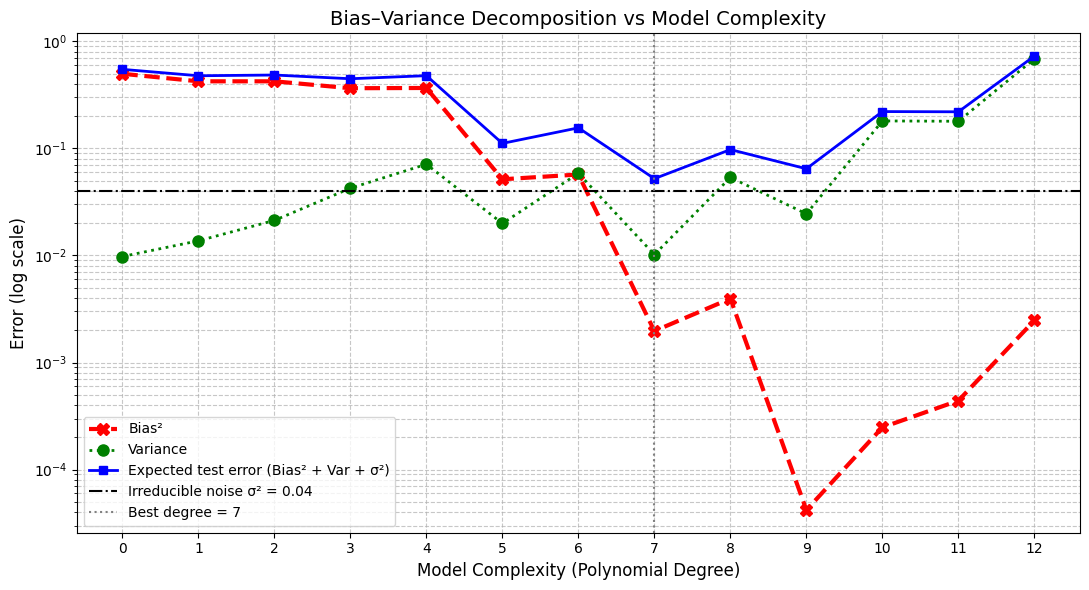

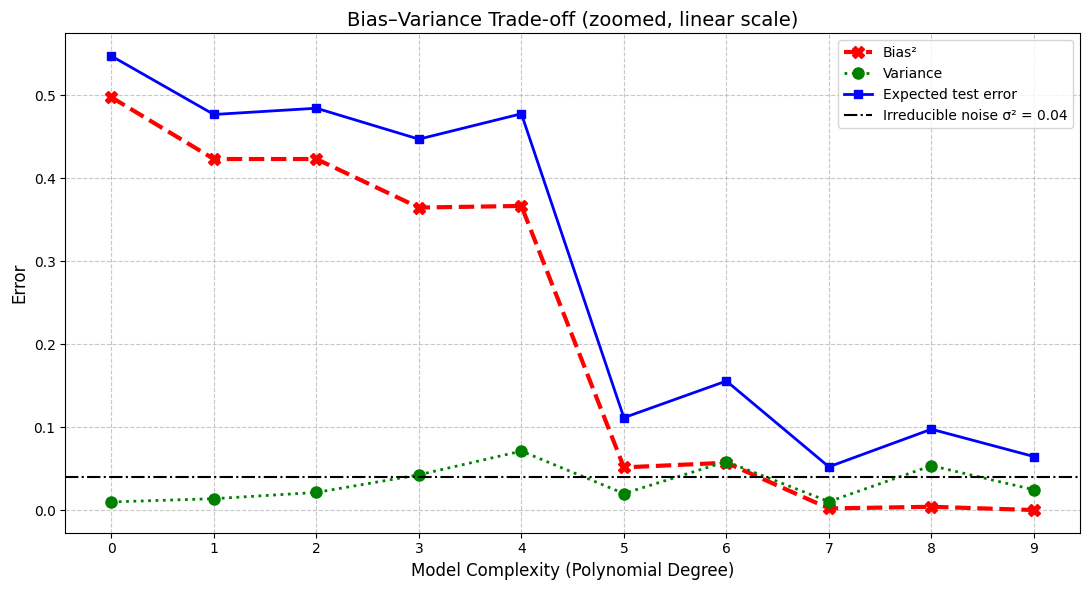

In [31]:
# Full picture. Variance grows by orders of magnitude, so the main plot uses a log scale.
plt.figure(figsize=(11, 6))
plt.plot(sweep_degrees, bias2_list, marker='X', color='red', linestyle='--',
         linewidth=3, markersize=9, label='Bias²')
plt.plot(sweep_degrees, variance_list, marker='o', color='green', linestyle=':',
         linewidth=2, markersize=8, label='Variance')
plt.plot(sweep_degrees, expected_error_list, marker='s', color='blue', linestyle='-',
         linewidth=2, markersize=6, label='Expected test error (Bias² + Var + σ²)')
plt.axhline(irreducible_noise, color='black', linestyle='-.', linewidth=1.5,
            label=f'Irreducible noise σ² = {irreducible_noise:.2f}')
plt.axvline(best_degree, color='gray', linestyle=':', label=f'Best degree = {best_degree}')
plt.yscale('log')
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Error (log scale)', fontsize=12)
plt.title('Bias–Variance Decomposition vs Model Complexity', fontsize=14)
plt.xticks(sweep_degrees)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Zoomed linear-scale view of the low-complexity region, where the U-shape is legible
zoom = [i for i, d in enumerate(sweep_degrees) if d <= 9]
plt.figure(figsize=(11, 6))
plt.plot([sweep_degrees[i] for i in zoom], [bias2_list[i] for i in zoom],
         marker='X', color='red', linestyle='--', linewidth=3, markersize=9, label='Bias²')
plt.plot([sweep_degrees[i] for i in zoom], [variance_list[i] for i in zoom],
         marker='o', color='green', linestyle=':', linewidth=2, markersize=8, label='Variance')
plt.plot([sweep_degrees[i] for i in zoom], [expected_error_list[i] for i in zoom],
         marker='s', color='blue', linewidth=2, markersize=6, label='Expected test error')
plt.axhline(irreducible_noise, color='black', linestyle='-.', linewidth=1.5,
            label=f'Irreducible noise σ² = {irreducible_noise:.2f}')
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Bias–Variance Trade-off (zoomed, linear scale)', fontsize=14)
plt.xticks([sweep_degrees[i] for i in zoom])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### The decomposition

The table printed above is a numerical check of a standard result. For a fixed test input $x$, with
$y = f(x) + \epsilon$ and $\epsilon \sim \mathcal{N}(0, \sigma^2)$ independent of the training set:

$$\mathbb{E}\big[(y - \hat{f}_D(x))^2\big]
= \underbrace{\big(\mathbb{E}_D[\hat{f}_D(x)] - f(x)\big)^2}_{\text{Bias}^2}
+ \underbrace{\mathbb{E}_D\big[(\hat{f}_D(x) - \mathbb{E}_D[\hat{f}_D(x)])^2\big]}_{\text{Variance}}
+ \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

The last term does not depend on the model at all. No amount of data or model tuning removes it —
it is the noise in the labels themselves, which is why the expected test error curve flattens out
towards $\sigma^2$ rather than towards zero.

In the printout, the column "Bias² + Var + σ²" and the column "Measured error" (computed by actually
scoring predictions against freshly drawn noisy targets) agree to within Monte Carlo error. The
decomposition is not a metaphor; it is an identity.

**The progression, in one place:**

```
Model complexity increases
        ↓
Bias  decreases   (a more flexible model can represent the truth)
Variance increases (a more flexible model depends more on which sample it saw)
        ↓
Expected test error = Bias² + Variance + σ²  →  often U-shaped
```

This is the answer to the question we posed at the end of Part 1. Training error only tracks how
well the model fits *this* sample; it is blind to variance. Test error pays for both terms, so it
turns back up once the variance gained outweighs the bias removed.

Three honest caveats:

* **The U is not smooth here.** $\sin(2\pi x)$ is an odd function about the origin, so even-degree
  terms buy almost no reduction in bias while still costing variance. That is why $\text{Bias}^2$
  barely moves from degree 1 to 2, and from 3 to 4, and why the error curve zigzags rather than
  descending cleanly.
* **The variance estimates are themselves noisy**, badly so at high degree. A single unlucky training
  sample can produce a wild fit that dominates the average, so re-running the cell with a different
  seed can move the high-degree numbers substantially. The trend is solid; individual values are not.
* **"More complexity eventually hurts" is a statement about this setup**: fixed training-set size,
  no regularization, ordinary least squares, and a test grid that includes the interval boundaries
  where polynomials are least stable. Change any of those and the picture changes.